# 04 Random Forest HR Employee Attrition

## Project Overview

This project develops an end-to-end machine learning solution for predicting employee attrition using the IBM HR Analytics Employee Attrition dataset.

The primary model is a Random Forest Classifier. The notebook includes extensive exploratory data analysis, reusable preprocessing, baseline and tuned Random Forest models, threshold analysis, feature importance, model comparison, production artifact serialization, and a final reusable training function.

## Project Objectives

- Understand the employee characteristics associated with attrition.
- Build a model that identifies employees at elevated attrition risk.
- Compare Random Forest with other classification algorithms.
- Evaluate the impact of hyperparameter tuning.
- Provide an interpretable and reusable machine learning pipeline.
- Save reports, figures, model artifacts, and processed data.

## Project Metadata

- Project name: `04_RandomForest_HRAttrition`
- Dataset: `WA_Fn-UseC_-HR-Employee-Attrition.csv`
- Target variable: `Attrition`
- Positive class: `Yes`
- Primary algorithm: Random Forest Classifier
- Primary metric: ROC-AUC
- Supporting metrics: Accuracy, Precision, Recall, F1-score

In [1]:
from pathlib import Path
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid")

print("Environment setup completed successfully.")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")

Environment setup completed successfully.
XGBoost available: True


## Phase 1: Business Understanding

Employee attrition refers to employees voluntarily or involuntarily leaving an organization. High attrition can create recruitment costs, productivity loss, knowledge loss, team instability, and increased workload for remaining employees.

A predictive attrition model can help Human Resources teams:

- Identify employees who may require early engagement.
- Prioritize retention programs.
- Investigate organizational patterns associated with turnover.
- Improve workforce planning.
- Support evidence-based HR decisions.

This is an imbalanced binary classification problem because employees who remain substantially outnumber employees who leave.

The positive class is defined as `Attrition = Yes`. The two important error types are:

- False negative: an employee who leaves is predicted to remain.
- False positive: an employee who remains is predicted to leave.

False negatives are often costly because the organization may lose the opportunity to intervene. However, false positives may also lead to unnecessary retention actions. Therefore, the model is evaluated with multiple metrics rather than accuracy alone.

Random Forest is selected as the primary algorithm because it:

- Captures nonlinear relationships.
- Models interactions between HR variables.
- Reduces the instability of a single Decision Tree.
- Supports class weighting.
- Provides feature-importance estimates.
- Performs well on structured tabular data.

In [2]:
business_definition = {
    "problem_type": "Binary classification",
    "target": "Attrition",
    "positive_class": "Yes",
    "primary_model": "Random Forest Classifier",
    "primary_metric": "ROC-AUC",
    "supporting_metrics": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
    ],
}

business_definition

{'problem_type': 'Binary classification',
 'target': 'Attrition',
 'positive_class': 'Yes',
 'primary_model': 'Random Forest Classifier',
 'primary_metric': 'ROC-AUC',
 'supporting_metrics': ['Accuracy', 'Precision', 'Recall', 'F1-score']}

## Phase 2: Data Ingestion and Structural Inspection

The dataset is loaded using robust path resolution so that the notebook can be executed from the repository root or the `notebooks` directory.

The initial inspection includes:

- Dataset dimensions.
- First observations.
- Column names.
- Data types.
- Non-null counts.
- Memory usage.

In [3]:
candidate_data_paths = [
    Path("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    Path("data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    Path("WA_Fn-UseC_-HR-Employee-Attrition.csv"),
    Path("/mnt/data/WA_Fn-UseC_-HR-Employee-Attrition.csv"),
]

data_path = next(
    (path for path in candidate_data_paths if path.exists()),
    None,
)

if data_path is None:
    checked_paths = "\n".join(
        str(path.resolve()) for path in candidate_data_paths
    )
    raise FileNotFoundError(
        "The HR attrition dataset was not found. "
        f"Checked the following paths:\n{checked_paths}"
    )

df = pd.read_csv(data_path)

print(f"Dataset path: {data_path.resolve()}")
print(f"Dataset dimensions: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
print(f"Columns: {df.columns.tolist()}")

display(df.head())

print("\nDataset information:")
df.info()

Dataset path: C:\Users\soham\Desktop\ahmed\NTI-ML\04_RandomForest_HRAttrition\data\raw\WA_Fn-UseC_-HR-Employee-Attrition.csv
Dataset dimensions: 1,470 rows and 35 columns
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  147

## Phase 3: Data Quality Assessment and Cleaning

The quality assessment checks:

- Missing values.
- Exact duplicate rows.
- Duplicate employee identifiers.
- Constant columns.
- Target validity.
- Numerical ranges.
- Categorical domains.

Administrative identifiers and constant columns are removed because they provide no meaningful predictive information.

The following columns are expected to be removed:

- `EmployeeNumber`: unique administrative identifier.
- `EmployeeCount`: constant value.
- `Over18`: constant value.
- `StandardHours`: constant value.

In [4]:
clean_df = df.copy()

print(f"Exact duplicate rows: {clean_df.duplicated().sum():,}")

if "EmployeeNumber" in clean_df.columns:
    print(
        "Duplicate EmployeeNumber values: "
        f"{clean_df['EmployeeNumber'].duplicated().sum():,}"
    )

missing_summary = (
    clean_df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_percentage=lambda table:
        table["missing_count"] / len(clean_df) * 100
    )
)

display(missing_summary)

constant_columns = [
    column
    for column in clean_df.columns
    if clean_df[column].nunique(dropna=False) <= 1
]

identifier_columns = [
    column
    for column in ["EmployeeNumber"]
    if column in clean_df.columns
]

columns_to_drop = sorted(
    set(constant_columns + identifier_columns)
)

clean_df = clean_df.drop(columns=columns_to_drop).copy()

target_column = "Attrition"

if target_column not in clean_df.columns:
    raise KeyError(
        f"Target column '{target_column}' was not found."
    )

expected_target_values = {"Yes", "No"}
observed_target_values = set(clean_df[target_column].unique())

if observed_target_values != expected_target_values:
    raise ValueError(
        "Unexpected target values were detected. "
        f"Observed values: {observed_target_values}"
    )

print(f"Constant columns: {constant_columns}")
print(f"Dropped columns: {columns_to_drop}")
print(f"Cleaned dataset dimensions: {clean_df.shape}")

print("\nCleaned schema:")
print(clean_df.dtypes)

Exact duplicate rows: 0
Duplicate EmployeeNumber values: 0


,missing_count,missing_percentage
Age,0,0.0000
Attrition,0,0.0000
BusinessTravel,0,0.0000
DailyRate,0,0.0000
Department,0,0.0000
DistanceFromHome,0,0.0000
Education,0,0.0000
EducationField,0,0.0000
EmployeeCount,0,0.0000
EmployeeNumber,0,0.0000


Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Cleaned dataset dimensions: (1470, 31)

Cleaned schema:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel   

## Phase 4: Exploratory Data Analysis

The exploratory analysis is divided into:

- Target analysis.
- Categorical distributions.
- Attrition rates by categorical features.
- Numerical distributions.
- Outlier analysis.
- Numerical comparisons by attrition.
- Correlation analysis.
- Focused relationship analysis.
- Pivot-based attrition analysis.

The visualizations are descriptive and do not establish causal relationships.

In [5]:
target_counts = clean_df[target_column].value_counts()
target_percentages = (
    clean_df[target_column]
    .value_counts(normalize=True)
    .mul(100)
)

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})

display(target_distribution)

imbalance_ratio = (
    target_counts.get("No", 0)
    / max(target_counts.get("Yes", 0), 1)
)

print(f"Retained-to-attrition ratio: {imbalance_ratio:.2f}:1")

,count,percentage
Attrition,,
No,1233,83.8776
Yes,237,16.1224


Retained-to-attrition ratio: 5.20:1


### Target Distribution

The bar chart and pie chart show the class imbalance from two perspectives. The bar chart emphasizes absolute counts, while the pie chart emphasizes class proportions.

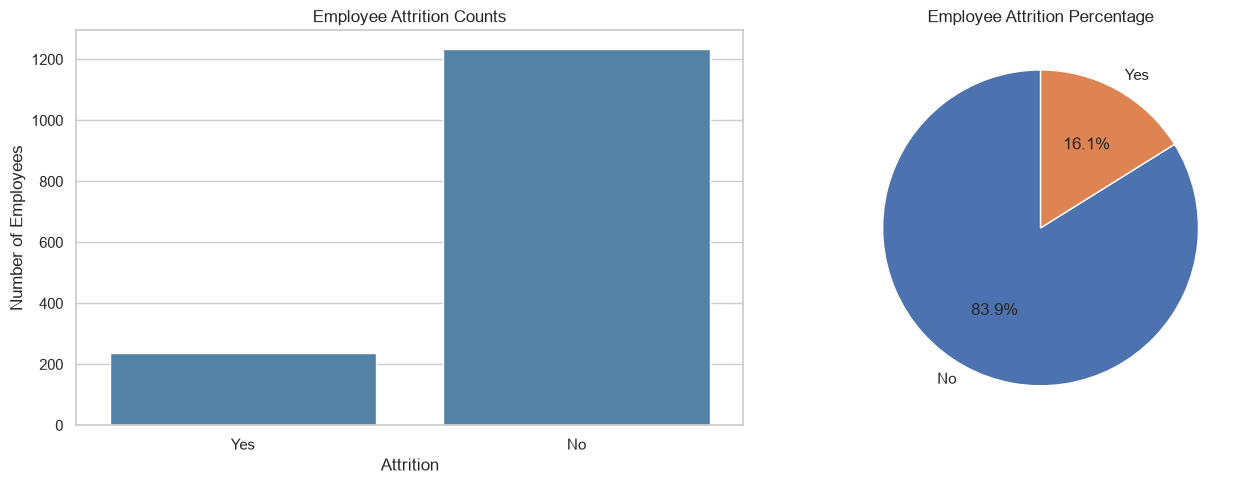

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=clean_df,
    x=target_column,
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Employee Attrition Counts")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Number of Employees")

target_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ylabel="",
    ax=axes[1],
)
axes[1].set_title("Employee Attrition Percentage")

plt.tight_layout()
plt.show()

### Categorical Feature Cardinality

Cardinality analysis shows the number of unique categories in each categorical variable. It helps identify variables that may generate many one-hot encoded features.

In [7]:
categorical_features_eda = (
    clean_df
    .select_dtypes(include=["object", "category"])
    .columns
    .drop(target_column)
    .tolist()
)

categorical_cardinality = pd.DataFrame({
    "feature": categorical_features_eda,
    "unique_values": [
        clean_df[column].nunique()
        for column in categorical_features_eda
    ],
}).sort_values("unique_values", ascending=False)

display(categorical_cardinality)

,feature,unique_values
4,JobRole,9
2,EducationField,6
0,BusinessTravel,3
1,Department,3
5,MaritalStatus,3
3,Gender,2
6,OverTime,2


### Categorical Distributions

Count plots show how employees are distributed across major categorical HR variables.

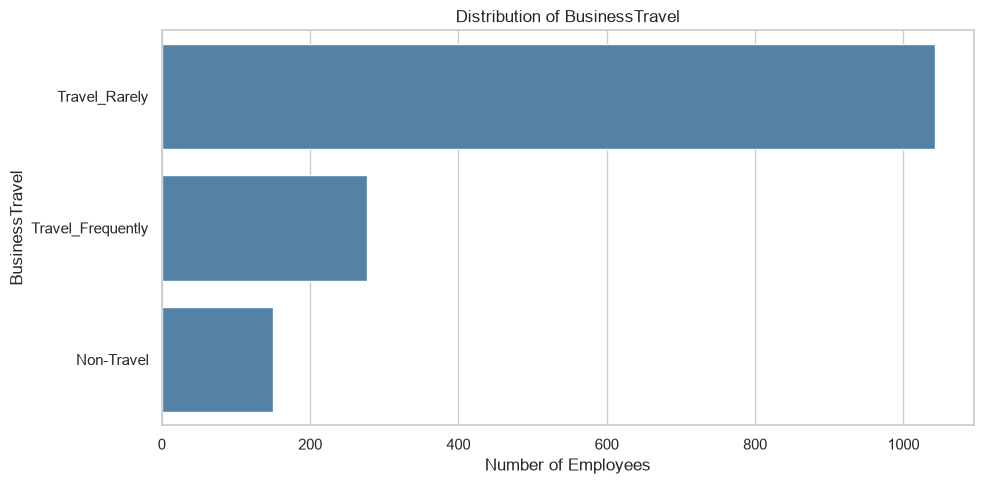

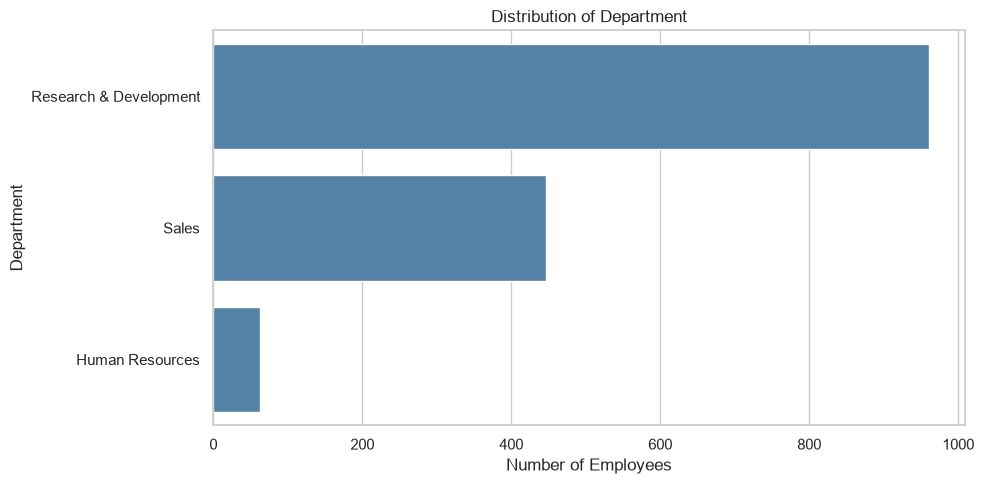

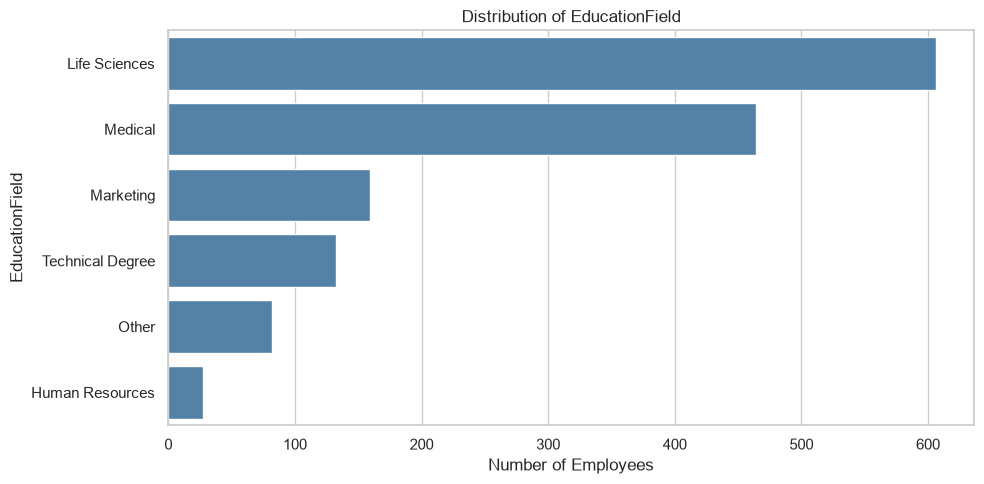

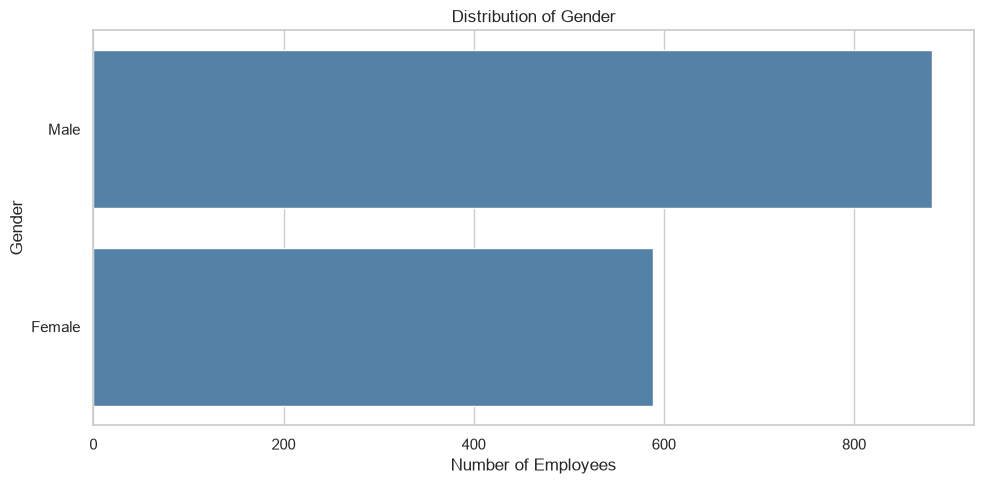

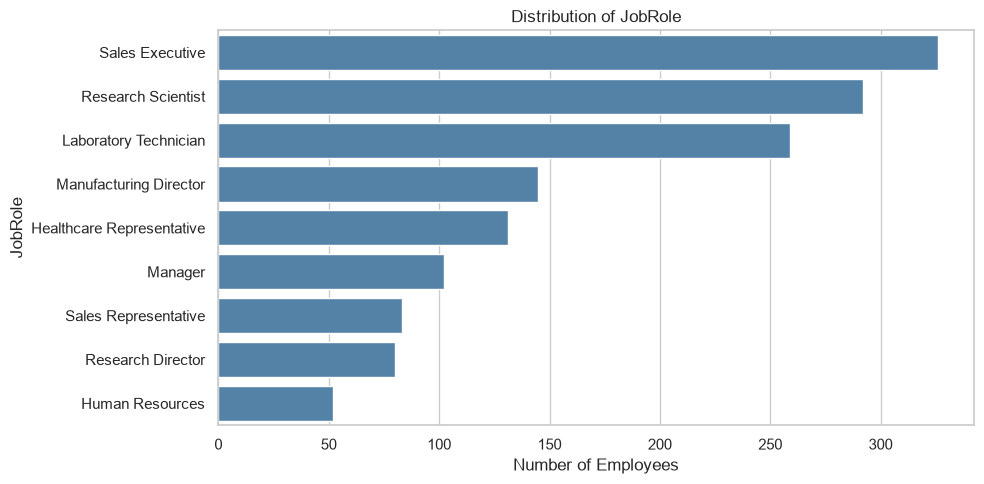

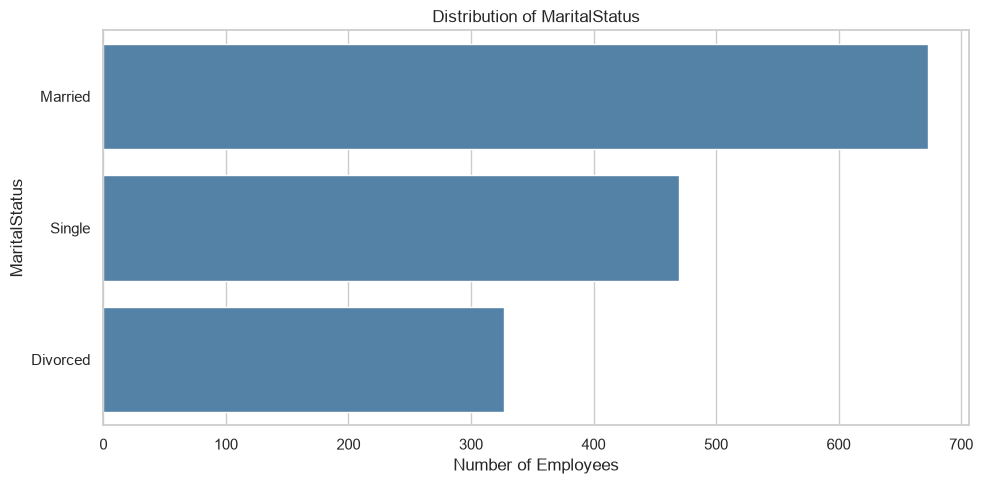

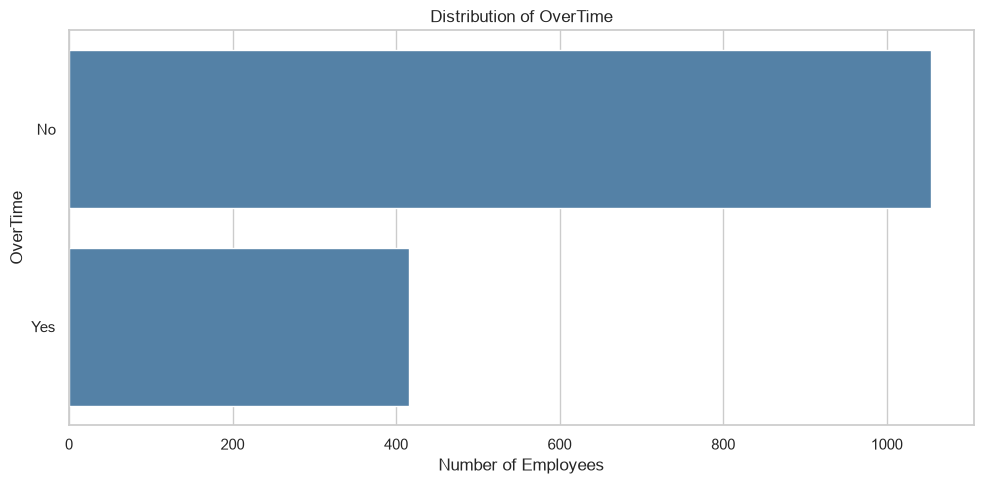

In [8]:
selected_categorical_features = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
]

available_categorical_features = [
    feature
    for feature in selected_categorical_features
    if feature in clean_df.columns
]

for feature in available_categorical_features:
    plt.figure(figsize=(10, 5))
    order = clean_df[feature].value_counts().index

    sns.countplot(
        data=clean_df,
        y=feature,
        order=order,
        color="steelblue",
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel("Number of Employees")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

### Attrition Rate by Categorical Feature

The observed attrition rate is calculated for every category. This is more informative than count plots alone because groups can have different sizes.

,employee_count,attrition_rate
BusinessTravel,,
Travel_Frequently,277,24.9097
Travel_Rarely,1043,14.9569
Non-Travel,150,8.0000


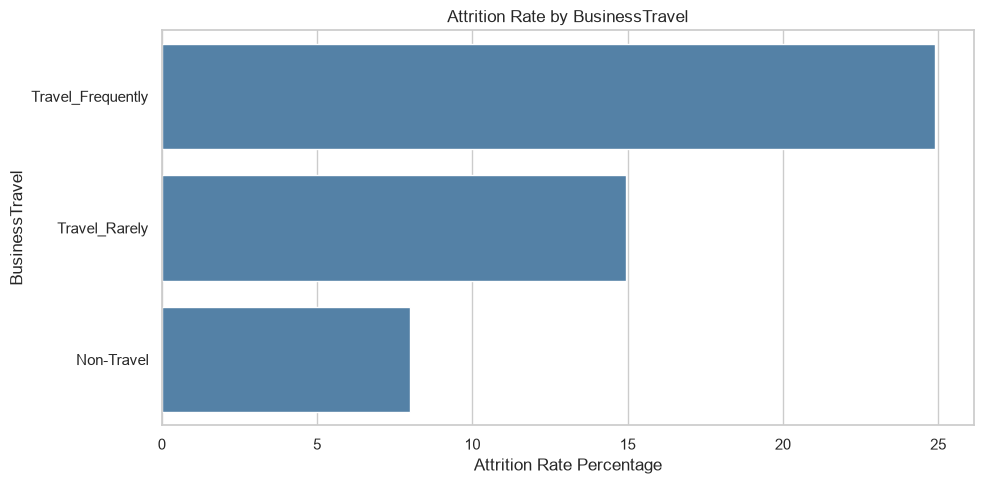

,employee_count,attrition_rate
Department,,
Sales,446,20.6278
Human Resources,63,19.0476
Research & Development,961,13.8398


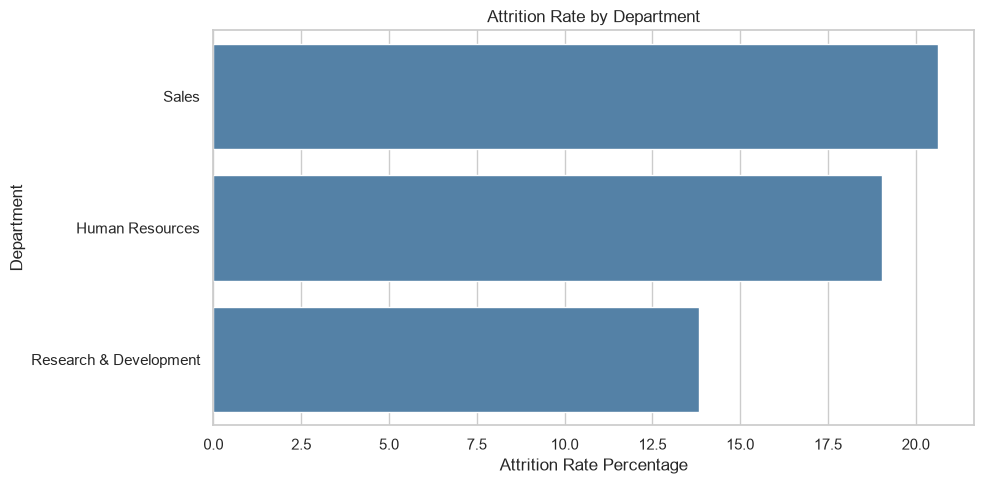

,employee_count,attrition_rate
EducationField,,
Human Resources,27,25.9259
Technical Degree,132,24.2424
Marketing,159,22.0126
Life Sciences,606,14.6865
Medical,464,13.5776
Other,82,13.4146


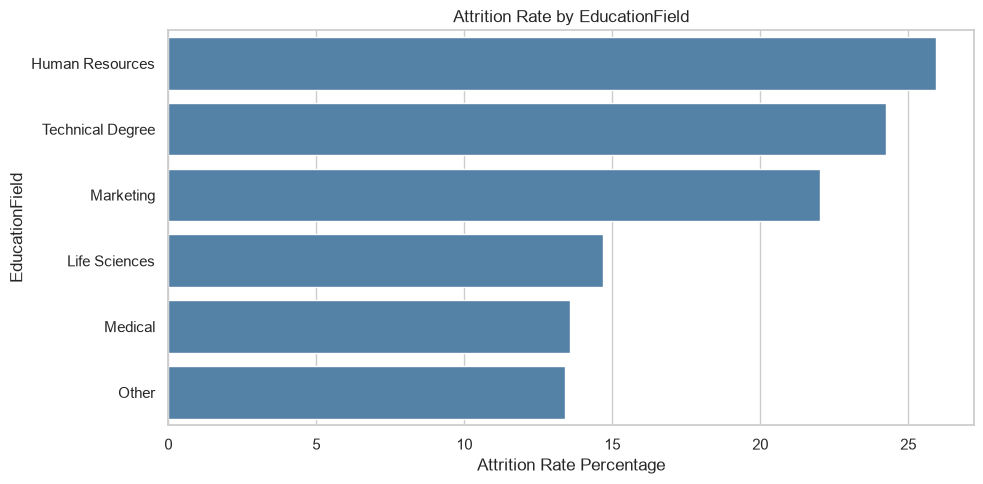

,employee_count,attrition_rate
Gender,,
Male,882,17.0068
Female,588,14.7959


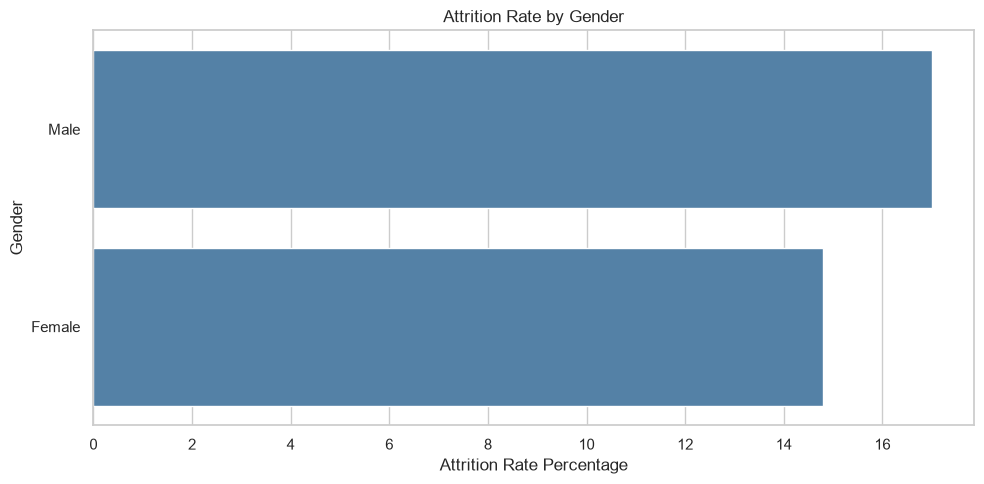

,employee_count,attrition_rate
JobRole,,
Sales Representative,83,39.7590
Laboratory Technician,259,23.9382
Human Resources,52,23.0769
Sales Executive,326,17.4847
Research Scientist,292,16.0959
Manufacturing Director,145,6.8966
Healthcare Representative,131,6.8702
Manager,102,4.9020
Research Director,80,2.5000


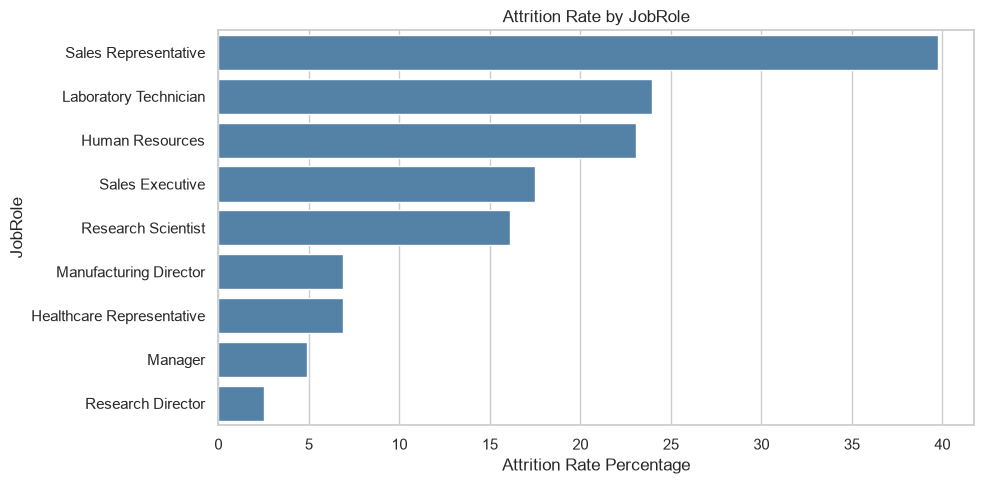

,employee_count,attrition_rate
MaritalStatus,,
Single,470,25.5319
Married,673,12.4814
Divorced,327,10.0917


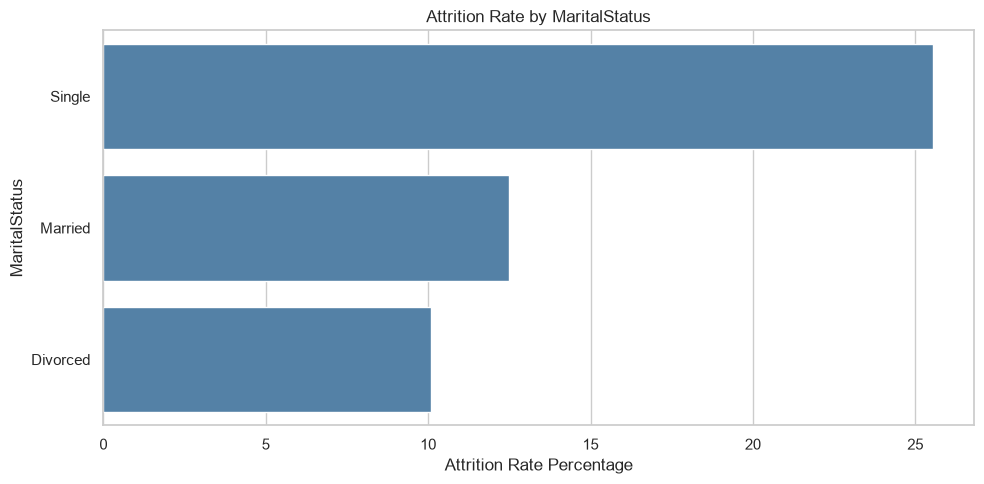

,employee_count,attrition_rate
OverTime,,
Yes,416,30.5288
No,1054,10.4364


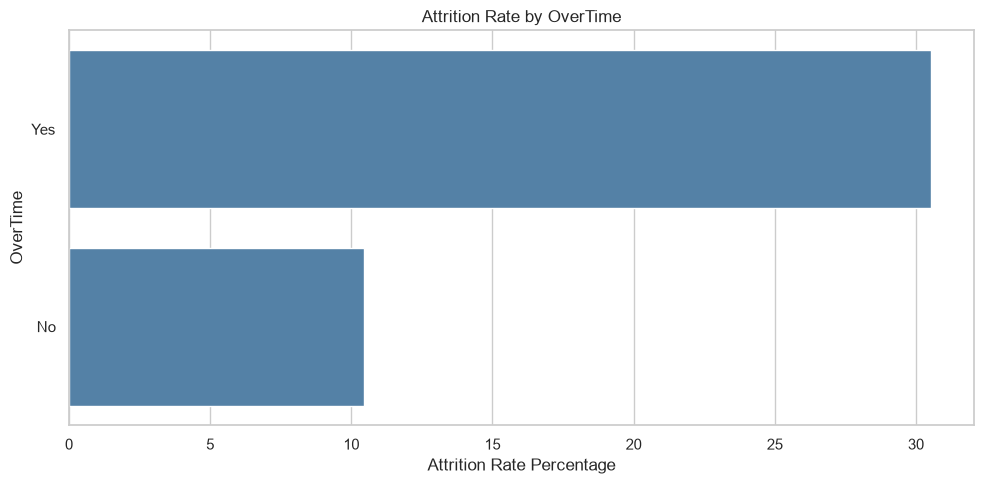

In [9]:
eda_df = clean_df.copy()
eda_df["AttritionBinary"] = (
    eda_df[target_column]
    .map({"No": 0, "Yes": 1})
)

for feature in available_categorical_features:
    attrition_rate_table = (
        eda_df.groupby(feature)["AttritionBinary"]
        .agg(employee_count="size", attrition_rate="mean")
        .assign(
            attrition_rate=lambda table:
            table["attrition_rate"] * 100
        )
        .sort_values("attrition_rate", ascending=False)
    )

    display(attrition_rate_table)

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=attrition_rate_table.reset_index(),
        x="attrition_rate",
        y=feature,
        color="steelblue",
    )

    plt.title(f"Attrition Rate by {feature}")
    plt.xlabel("Attrition Rate Percentage")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

### Numerical Summary Statistics

The numerical summary identifies central tendency, spread, and potential extreme values.

In [10]:
numerical_features_eda = (
    clean_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

display(clean_df[numerical_features_eda].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,"1,470.0000",36.9238,9.1354,18.0000,30.0000,36.0000,43.0000,60.0000
DailyRate,"1,470.0000",802.4857,403.5091,102.0000,465.0000,802.0000,"1,157.0000","1,499.0000"
DistanceFromHome,"1,470.0000",9.1925,8.1069,1.0000,2.0000,7.0000,14.0000,29.0000
Education,"1,470.0000",2.9129,1.0242,1.0000,2.0000,3.0000,4.0000,5.0000
EnvironmentSatisfaction,"1,470.0000",2.7218,1.0931,1.0000,2.0000,3.0000,4.0000,4.0000
HourlyRate,"1,470.0000",65.8912,20.3294,30.0000,48.0000,66.0000,83.7500,100.0000
JobInvolvement,"1,470.0000",2.7299,0.7116,1.0000,2.0000,3.0000,3.0000,4.0000
JobLevel,"1,470.0000",2.0639,1.1069,1.0000,1.0000,2.0000,3.0000,5.0000
JobSatisfaction,"1,470.0000",2.7286,1.1028,1.0000,2.0000,3.0000,4.0000,4.0000
MonthlyIncome,"1,470.0000","6,502.9313","4,707.9568","1,009.0000","2,911.0000","4,919.0000","8,379.0000","19,999.0000"


### Numerical Feature Distributions

Histograms with density curves show skewness, multimodality, and concentration patterns. The notebook focuses on the most business-relevant numerical variables.

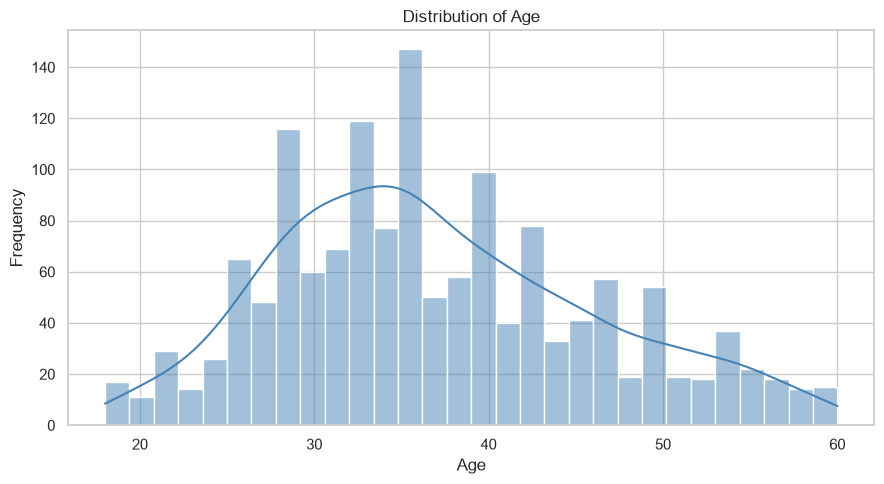

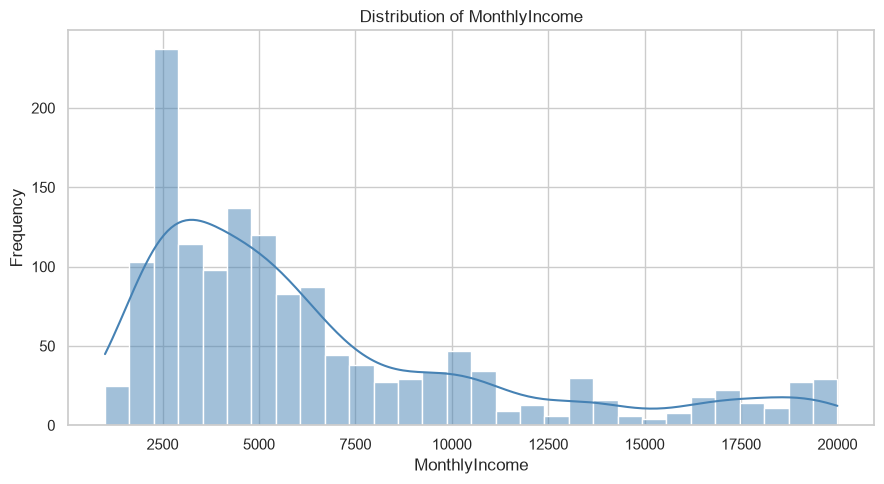

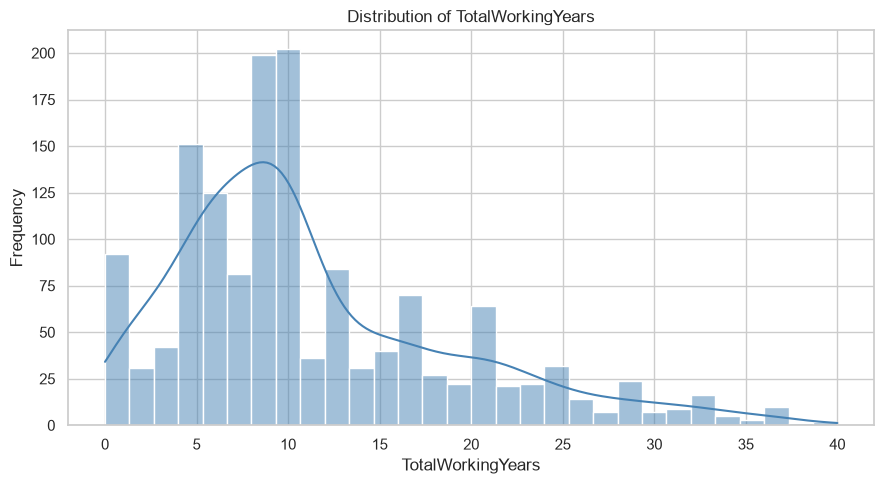

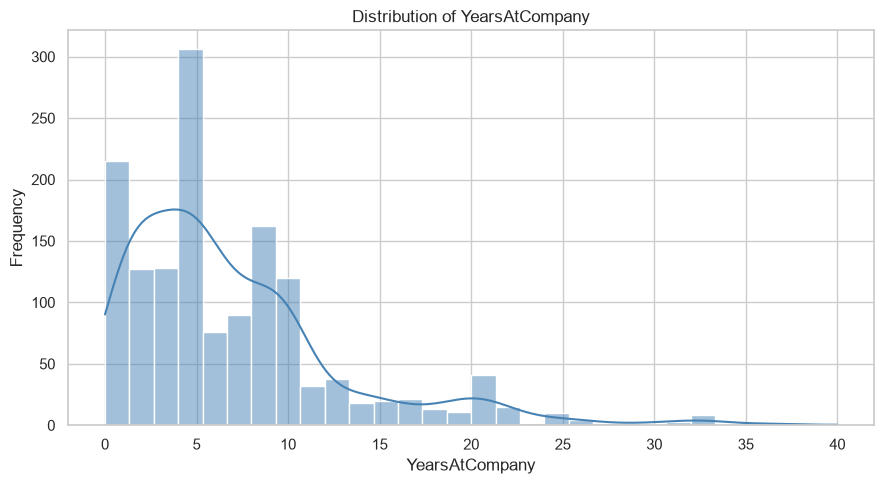

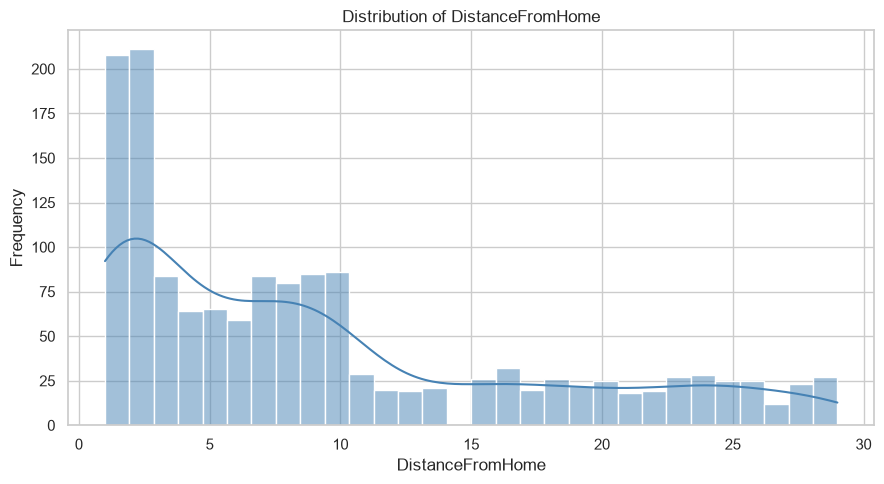

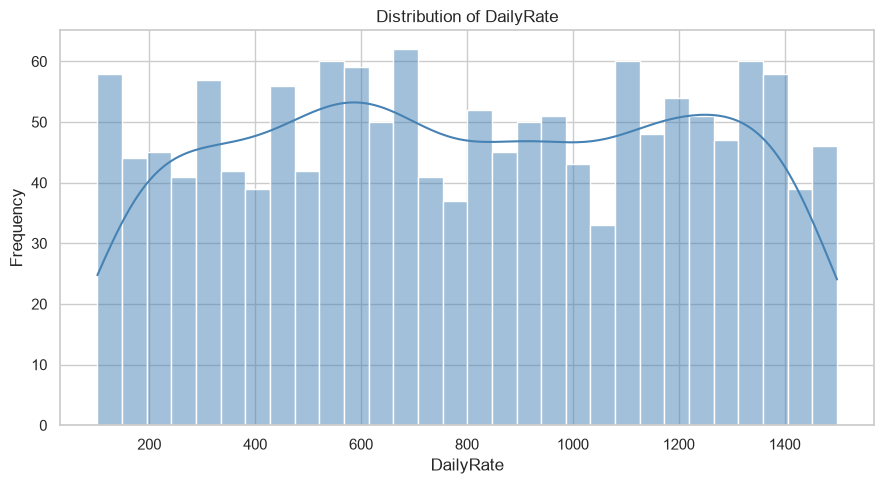

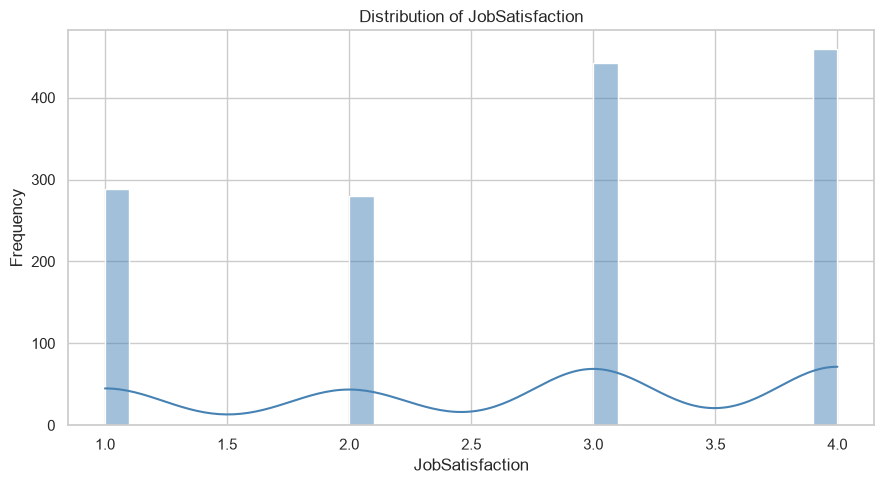

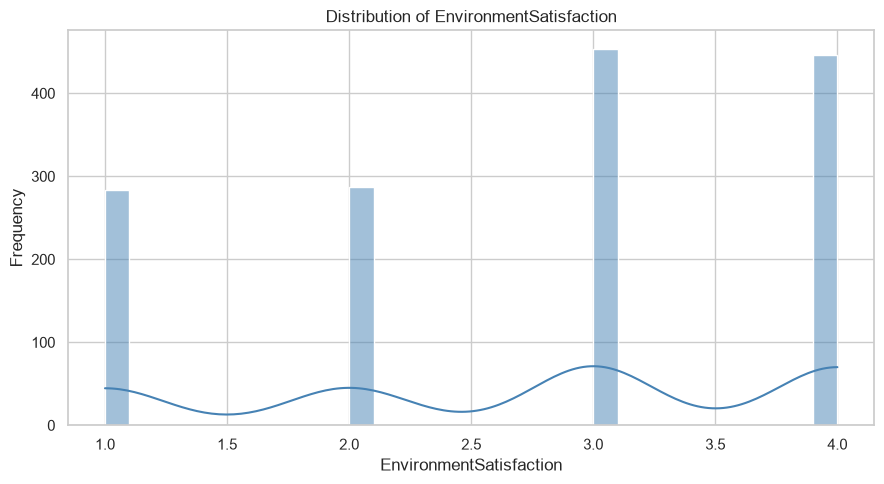

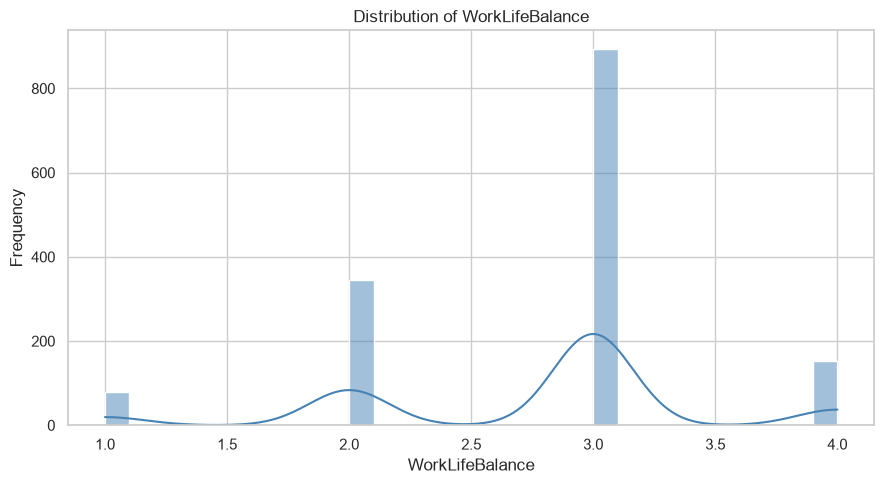

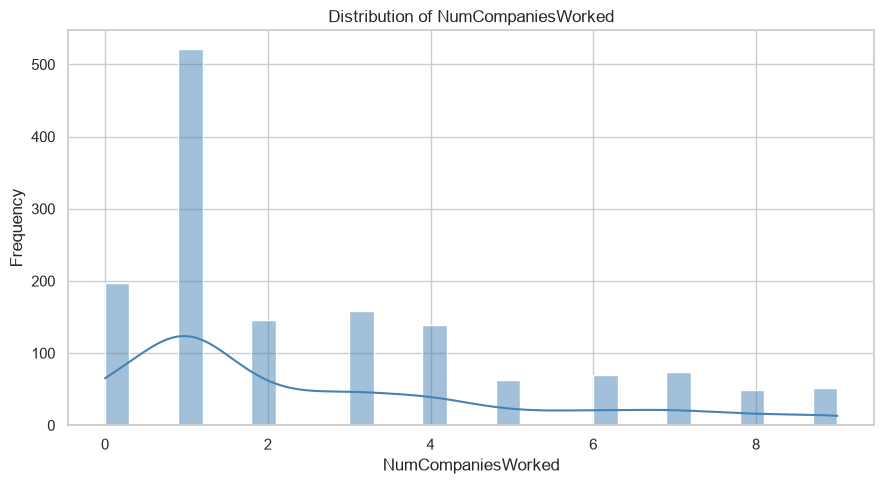

In [11]:
important_numerical_features = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "DistanceFromHome",
    "DailyRate",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "NumCompaniesWorked",
]

available_numerical_features = [
    feature
    for feature in important_numerical_features
    if feature in clean_df.columns
]

for feature in available_numerical_features:
    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=clean_df,
        x=feature,
        kde=True,
        bins=30,
        color="steelblue",
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Numerical Outlier Analysis

Boxplots show the central range and potential extreme observations. Outliers are not removed automatically because extreme values may represent valid employee characteristics.

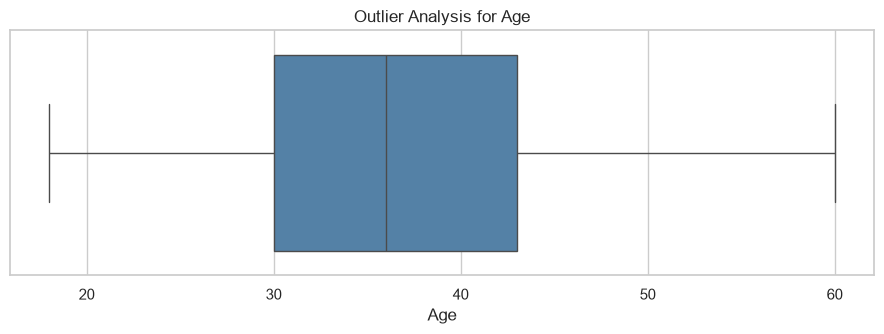

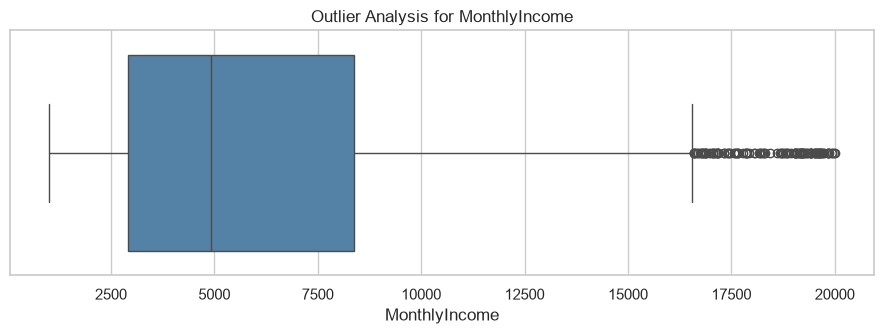

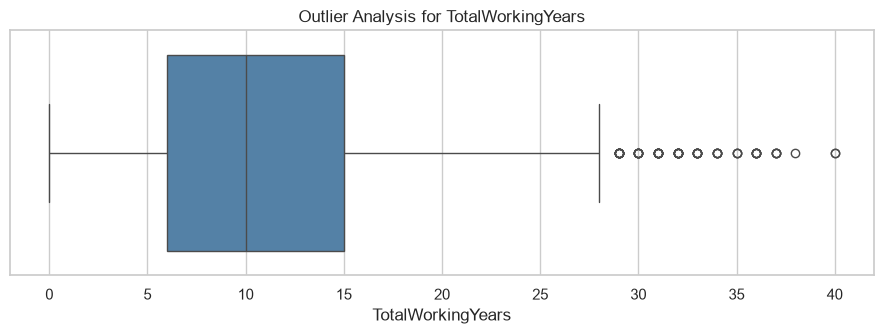

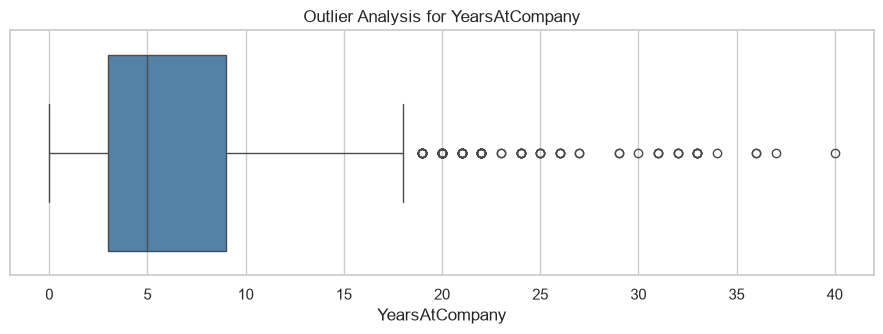

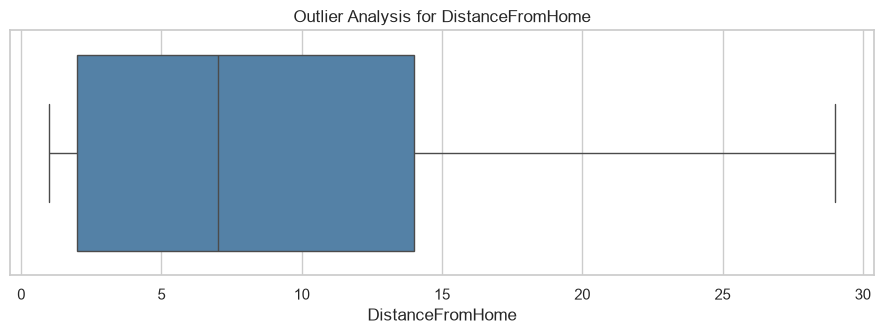

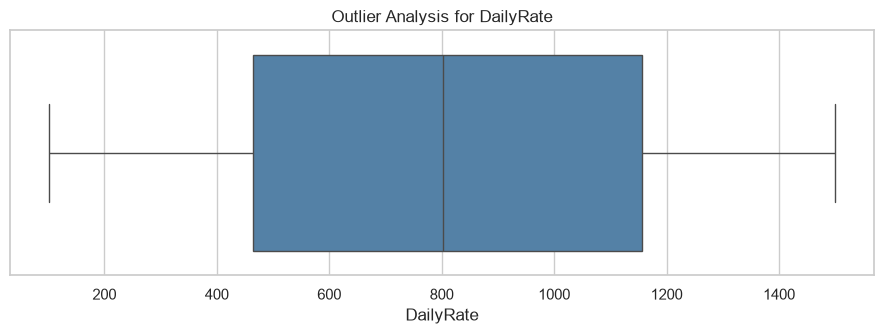

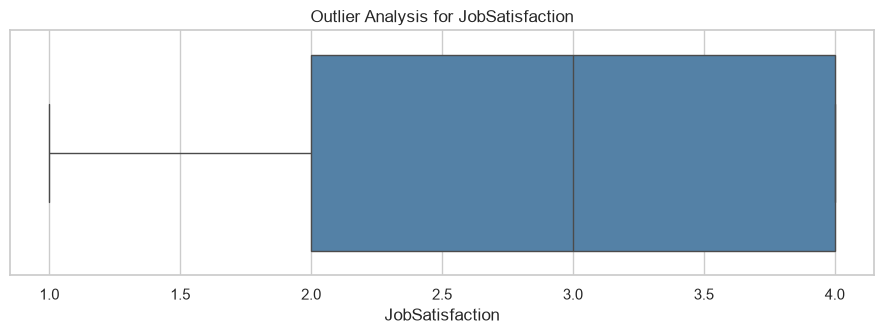

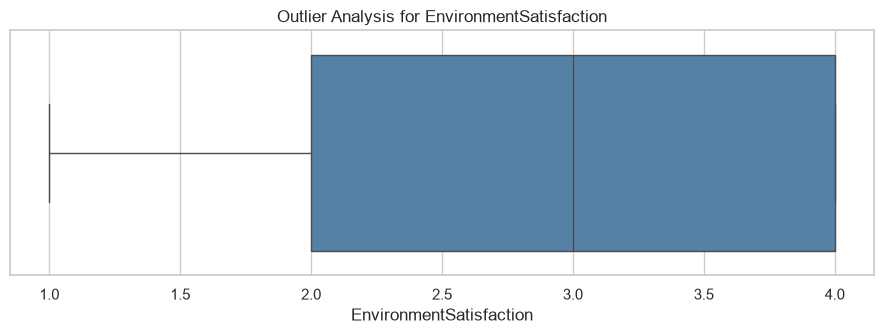

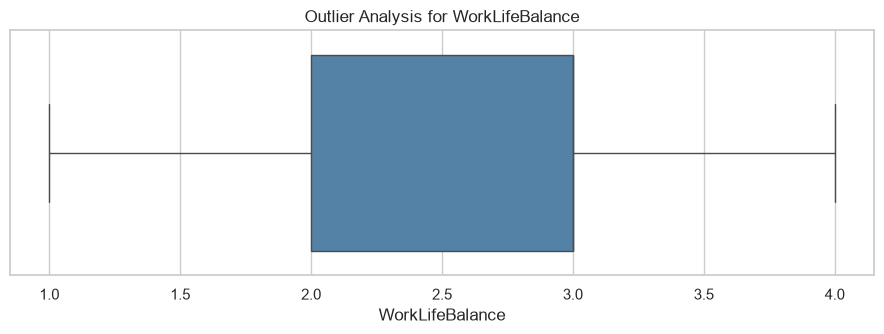

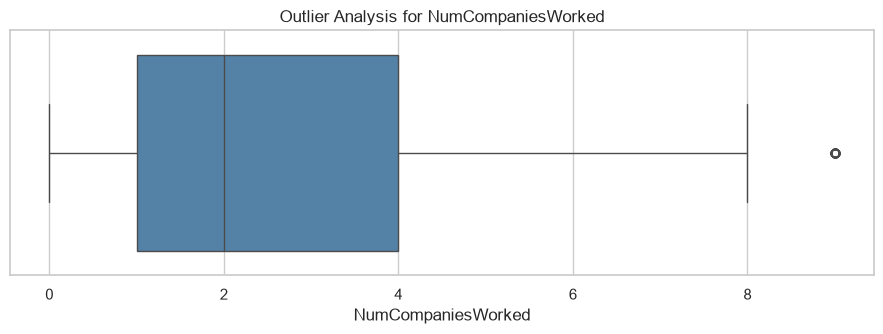

In [12]:
for feature in available_numerical_features:
    plt.figure(figsize=(9, 3.5))

    sns.boxplot(
        data=clean_df,
        x=feature,
        color="steelblue",
    )

    plt.title(f"Outlier Analysis for {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

### Numerical Features by Attrition Status

Split distributions and boxplots compare employees who stayed with employees who left.

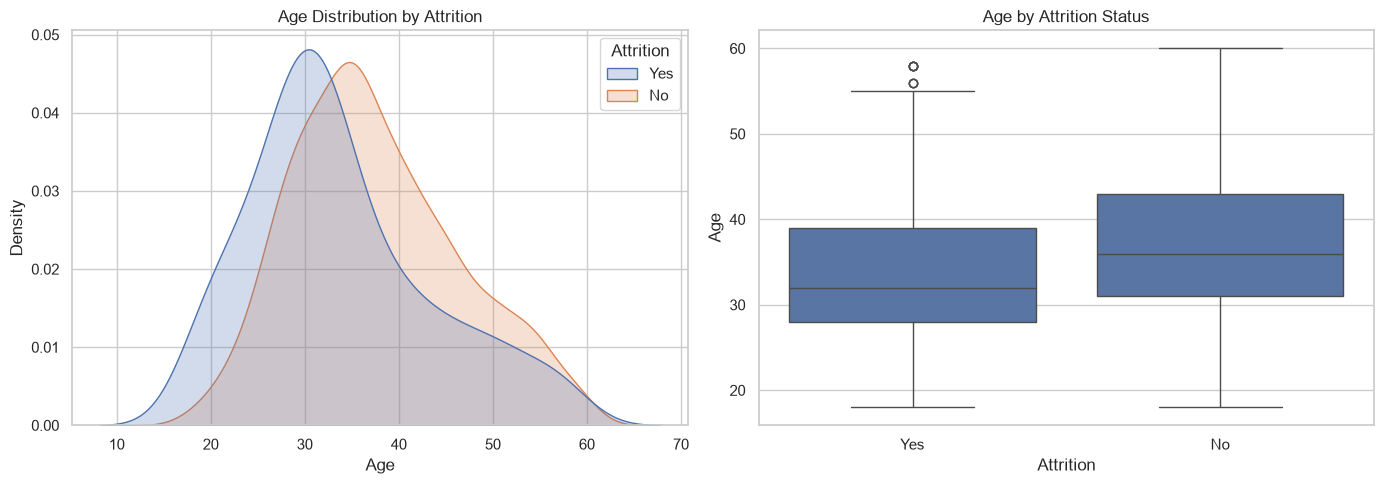

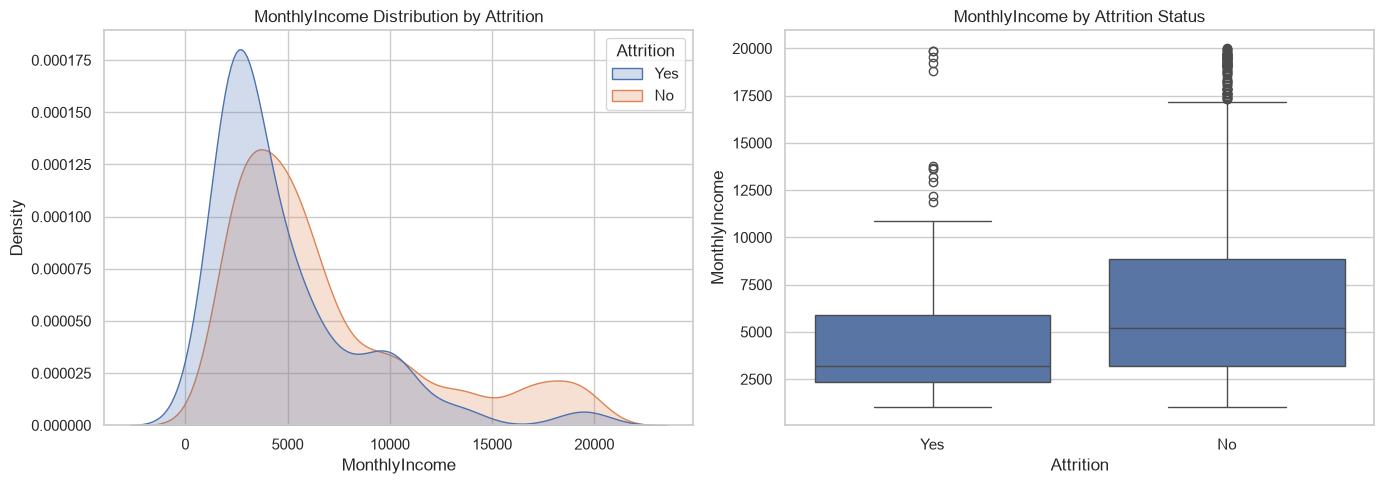

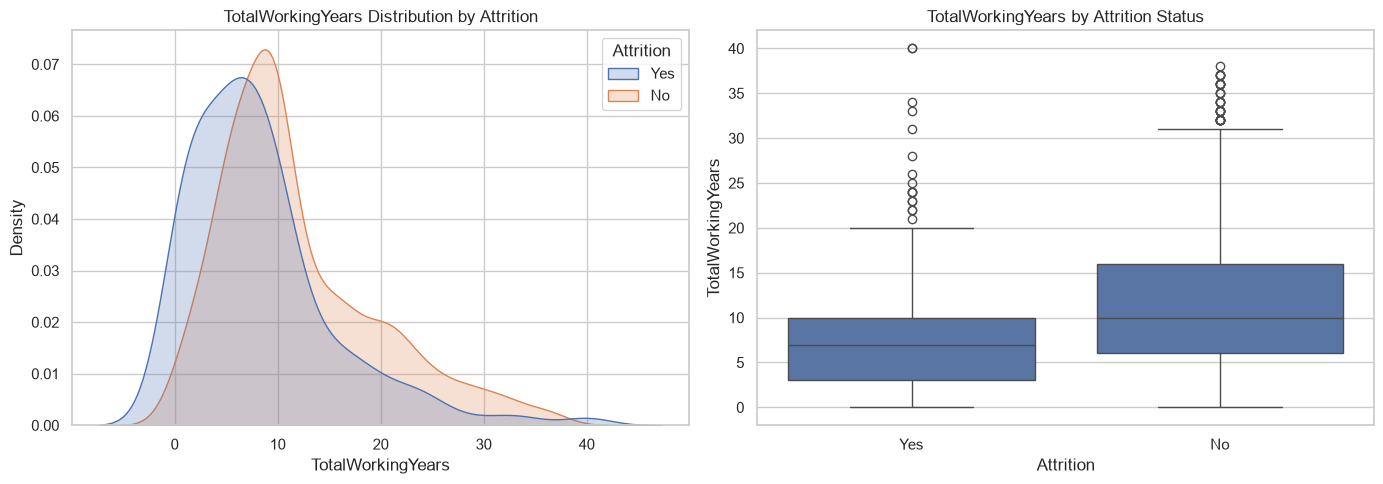

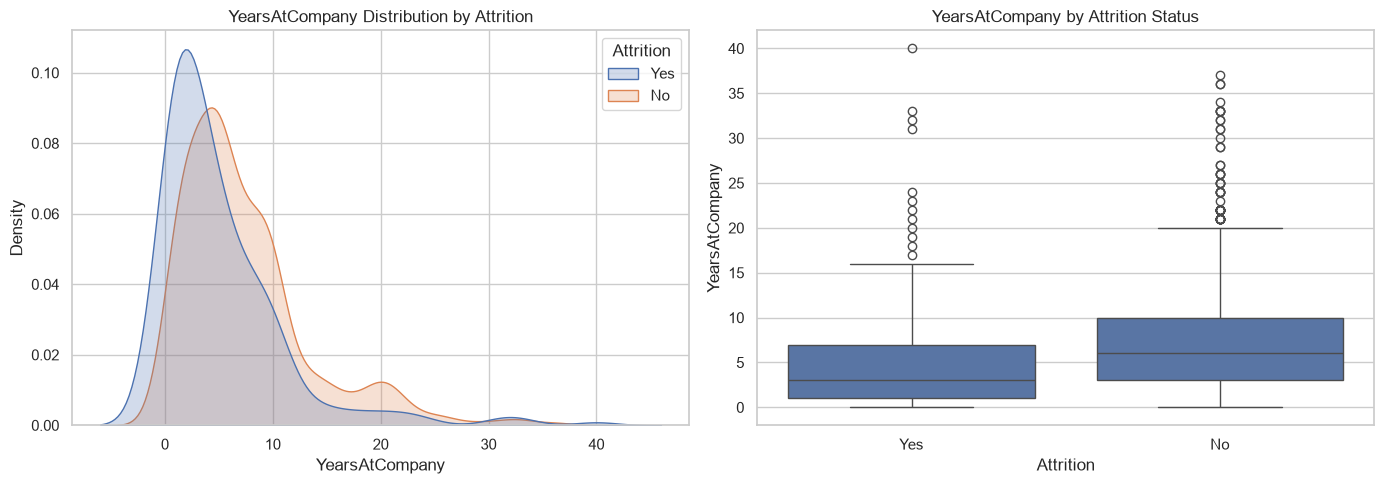

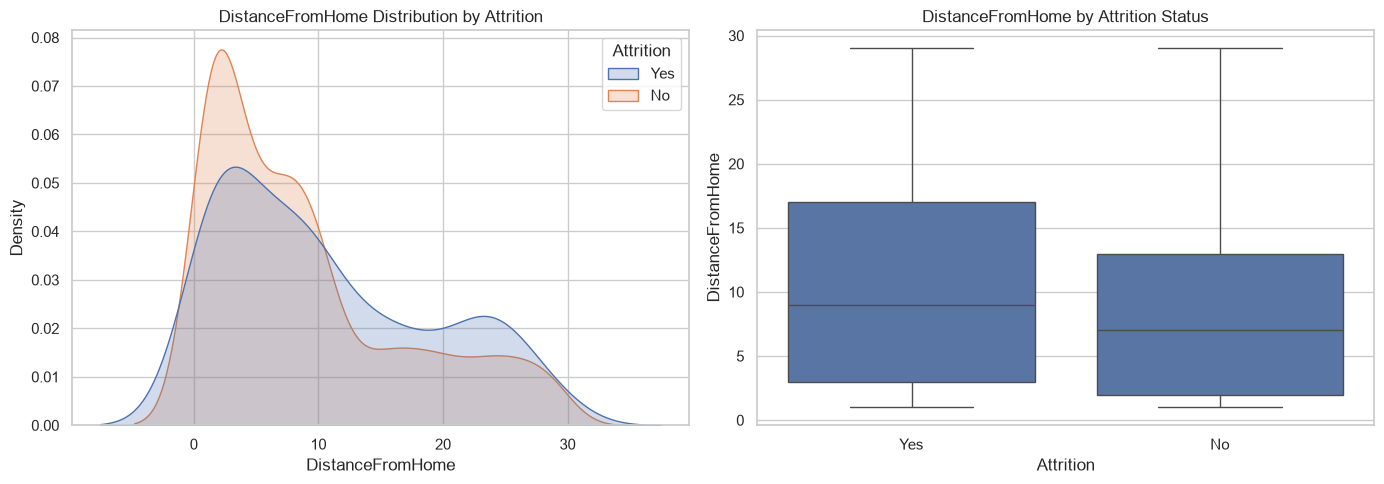

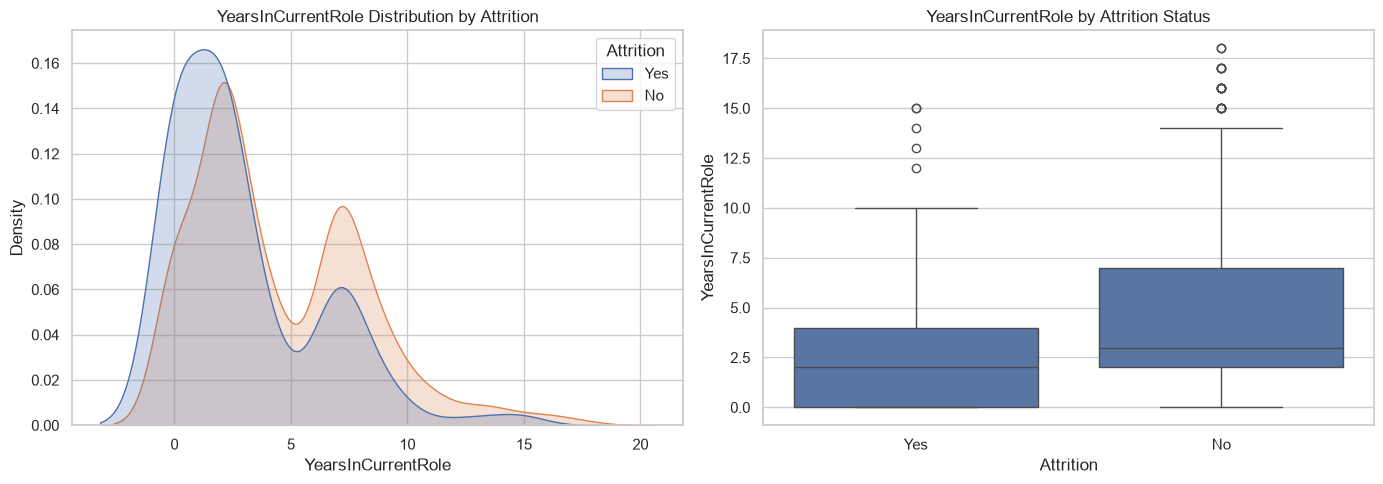

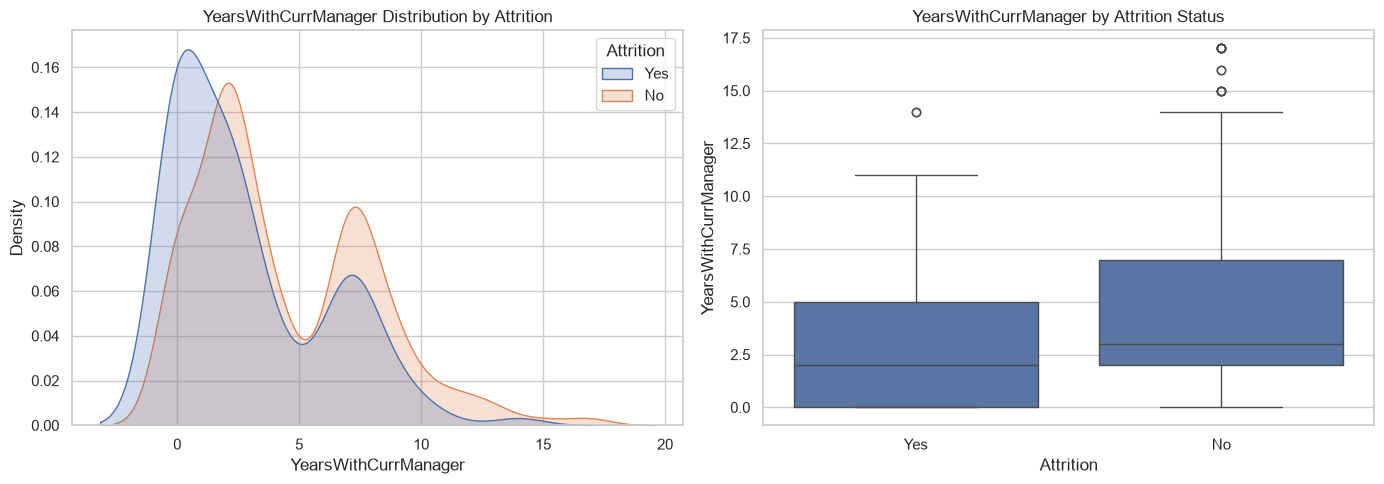

In [13]:
comparison_features = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "DistanceFromHome",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
]

available_comparison_features = [
    feature
    for feature in comparison_features
    if feature in clean_df.columns
]

for feature in available_comparison_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.kdeplot(
        data=clean_df,
        x=feature,
        hue=target_column,
        fill=True,
        common_norm=False,
        ax=axes[0],
    )
    axes[0].set_title(
        f"{feature} Distribution by Attrition"
    )

    sns.boxplot(
        data=clean_df,
        x=target_column,
        y=feature,
        ax=axes[1],
    )
    axes[1].set_title(
        f"{feature} by Attrition Status"
    )

    plt.tight_layout()
    plt.show()

### Attrition Rate by Satisfaction and Work Factors

Ordinal HR variables are grouped to observe how attrition changes across satisfaction, involvement, work-life balance, and job-level categories.

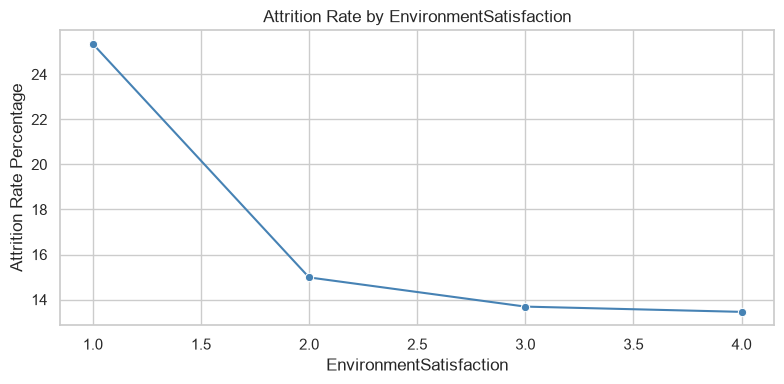

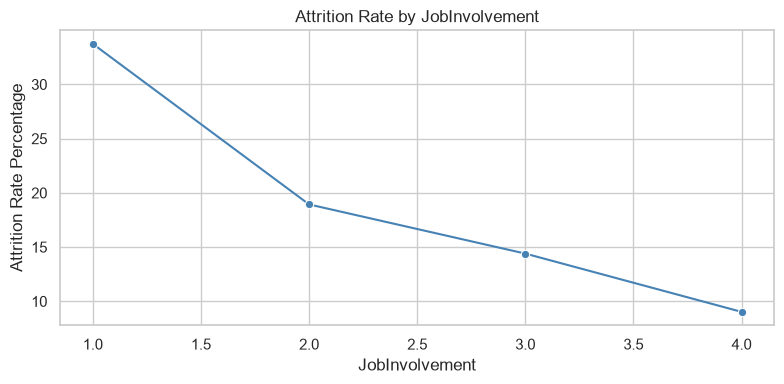

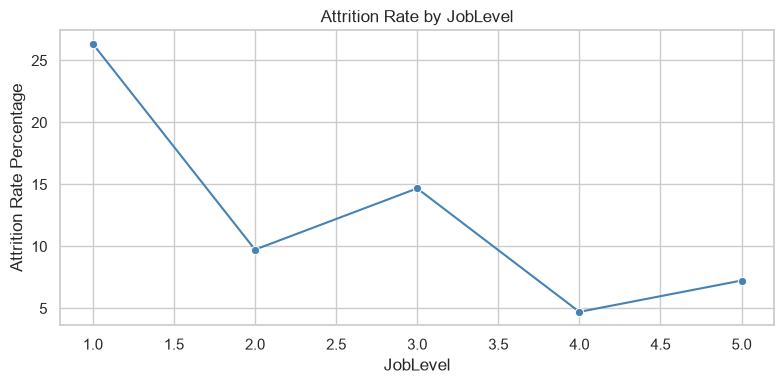

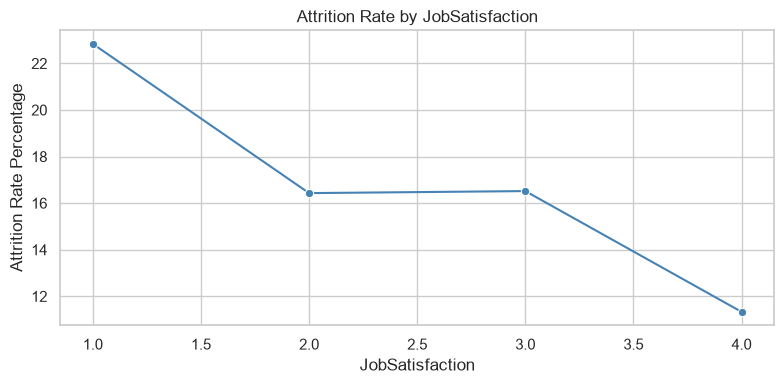

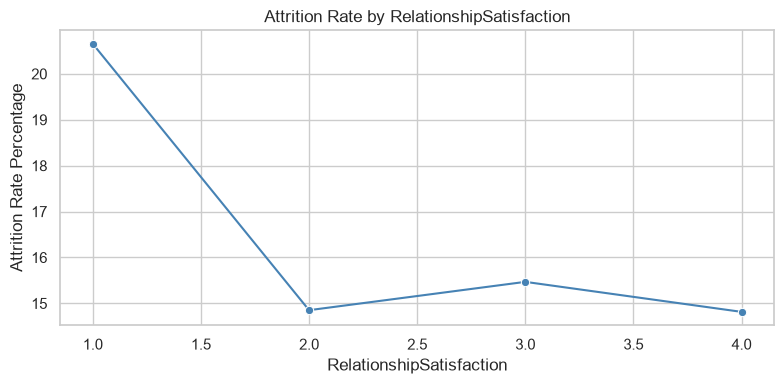

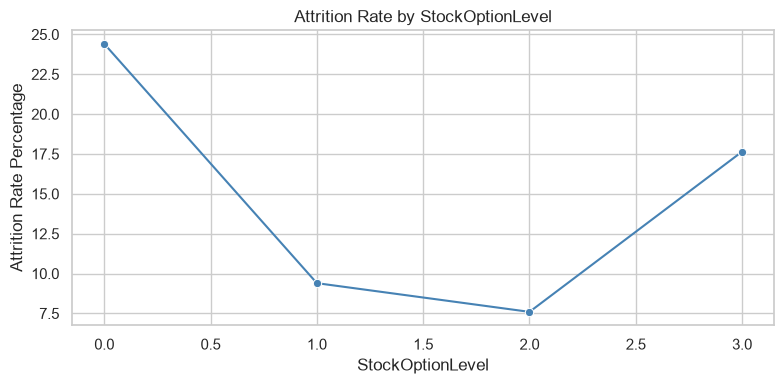

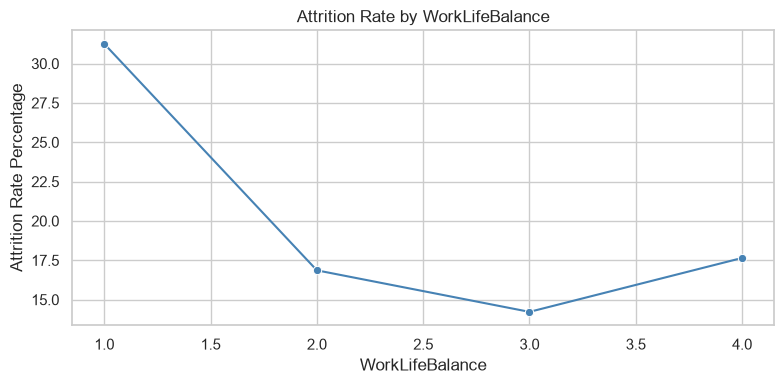

In [14]:
ordinal_features = [
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance",
]

available_ordinal_features = [
    feature
    for feature in ordinal_features
    if feature in eda_df.columns
]

for feature in available_ordinal_features:
    rate_data = (
        eda_df.groupby(feature)["AttritionBinary"]
        .mean()
        .mul(100)
        .reset_index(name="AttritionRate")
    )

    plt.figure(figsize=(8, 4))

    sns.lineplot(
        data=rate_data,
        x=feature,
        y="AttritionRate",
        marker="o",
        color="steelblue",
    )

    plt.title(f"Attrition Rate by {feature}")
    plt.ylabel("Attrition Rate Percentage")
    plt.tight_layout()
    plt.show()

### Overtime and Attrition

Overtime is analyzed using both counts and normalized proportions. The normalized chart highlights the probability of attrition within each overtime group.

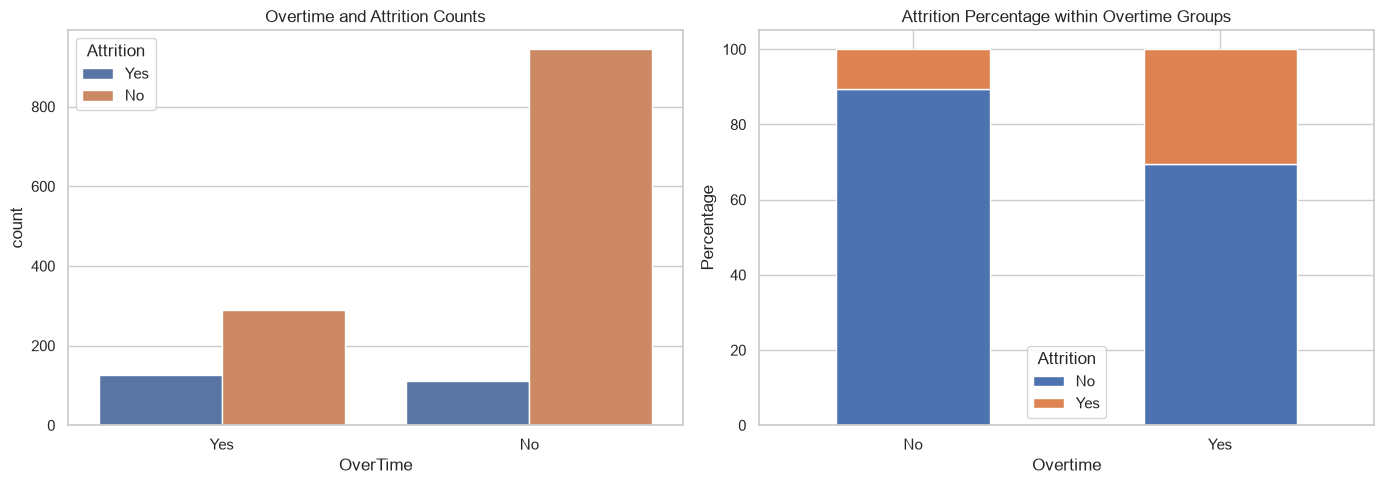

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=clean_df,
    x="OverTime",
    hue=target_column,
    ax=axes[0],
)
axes[0].set_title("Overtime and Attrition Counts")

overtime_proportions = pd.crosstab(
    clean_df["OverTime"],
    clean_df[target_column],
    normalize="index",
).mul(100)

overtime_proportions.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
)
axes[1].set_title("Attrition Percentage within Overtime Groups")
axes[1].set_xlabel("Overtime")
axes[1].set_ylabel("Percentage")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Monthly Income by Job Role

Monthly income varies strongly by job role. The boxplot provides context for interpreting income-related attrition patterns.

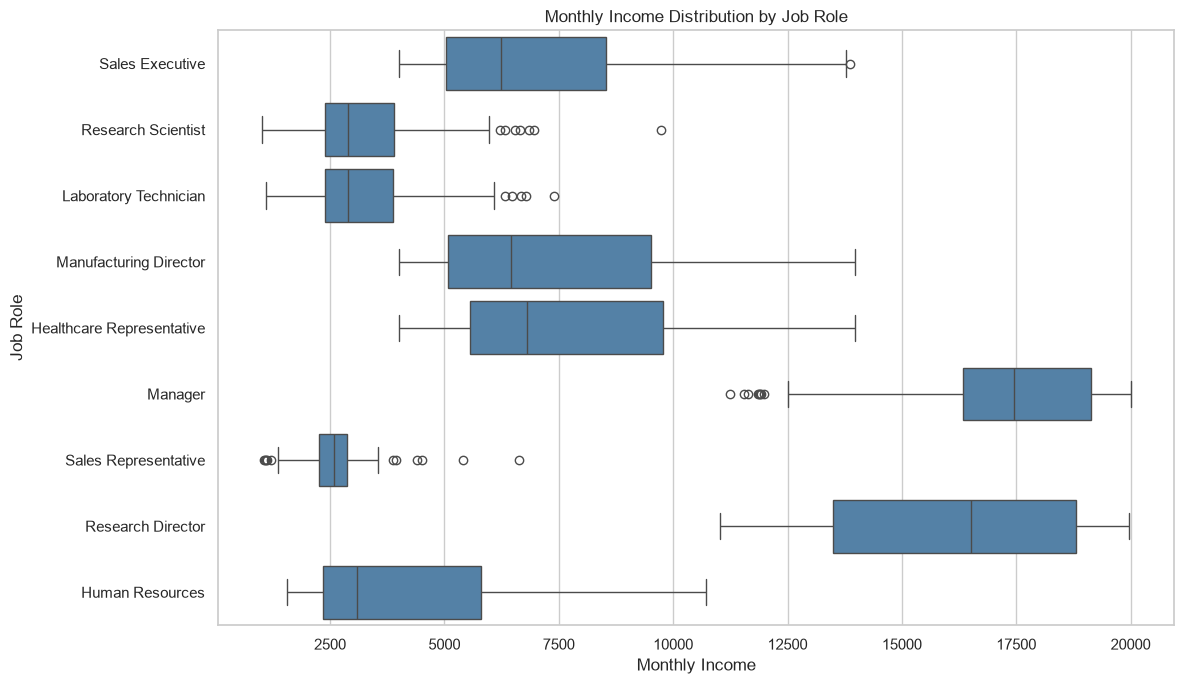

In [16]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=clean_df,
    x="MonthlyIncome",
    y="JobRole",
    color="steelblue",
)

plt.title("Monthly Income Distribution by Job Role")
plt.xlabel("Monthly Income")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

### Age and Monthly Income Relationship

The scatter plot examines the relationship between age and monthly income while distinguishing attrition outcomes.

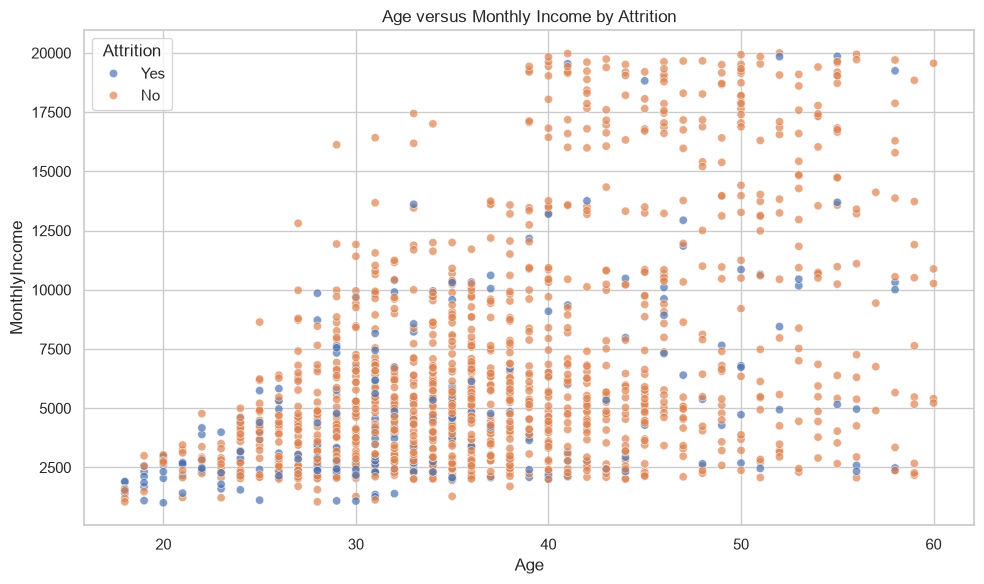

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Age",
    y="MonthlyIncome",
    hue=target_column,
    alpha=0.70,
)

plt.title("Age versus Monthly Income by Attrition")
plt.tight_layout()
plt.show()

### Years at Company and Attrition Rate

Employees are grouped by tenure at the company to observe how attrition varies over organizational tenure.

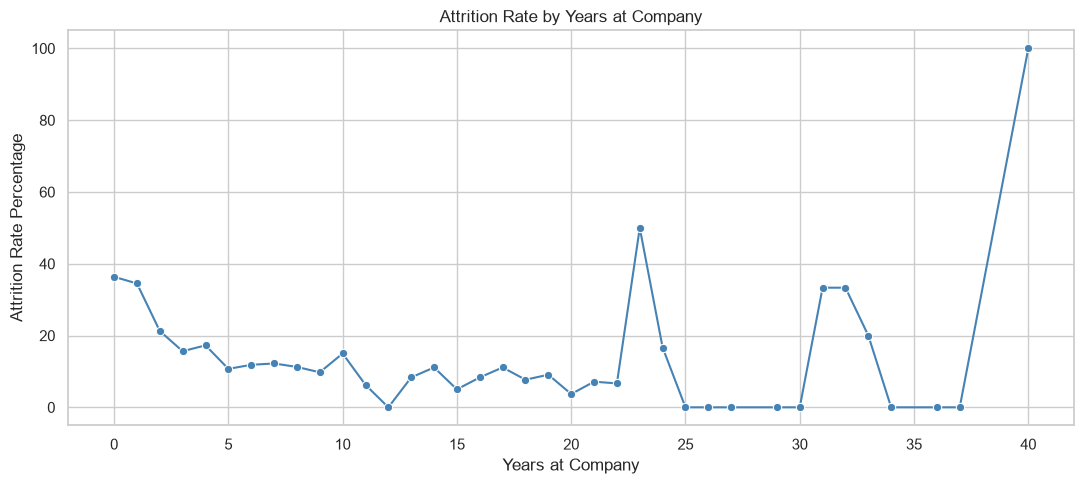

,YearsAtCompany,employee_count,attrition_rate
0,0,44,36.3636
1,1,171,34.5029
2,2,127,21.2598
3,3,128,15.6250
4,4,110,17.2727
5,5,196,10.7143
6,6,76,11.8421
7,7,90,12.2222
8,8,80,11.2500
9,9,82,9.7561


In [18]:
years_company_rate = (
    eda_df.groupby("YearsAtCompany")["AttritionBinary"]
    .agg(employee_count="size", attrition_rate="mean")
    .assign(
        attrition_rate=lambda table:
        table["attrition_rate"] * 100
    )
    .reset_index()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=years_company_rate,
    x="YearsAtCompany",
    y="attrition_rate",
    marker="o",
    color="steelblue",
)

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate Percentage")
plt.tight_layout()
plt.show()

display(years_company_rate.head(15))

### Department and Job Role Attrition Heatmap

The heatmap combines department and job role to reveal groups with higher observed attrition rates.

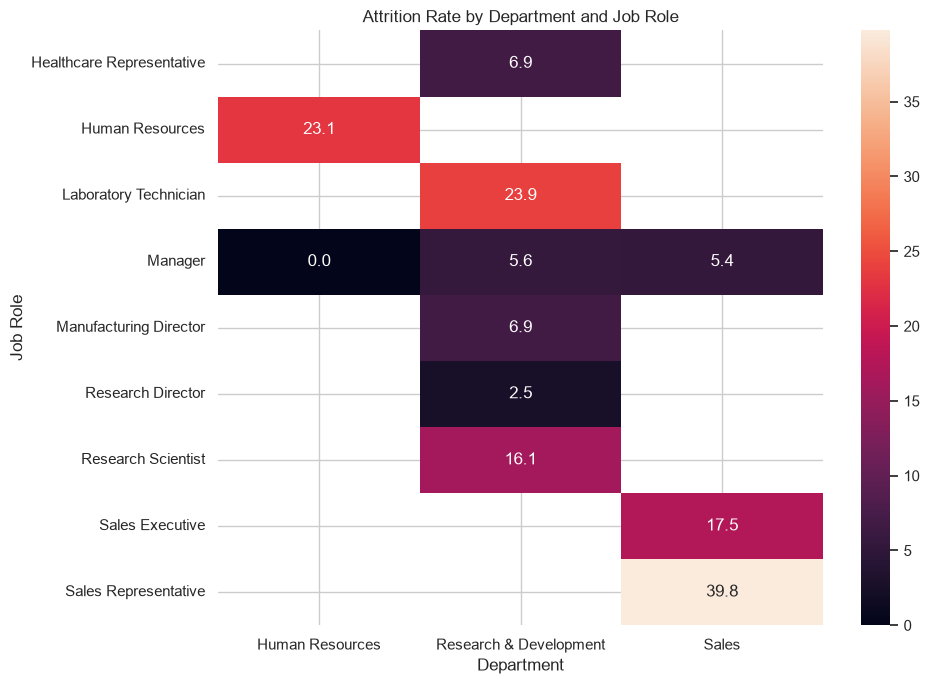

In [19]:
department_role_attrition = pd.pivot_table(
    eda_df,
    values="AttritionBinary",
    index="JobRole",
    columns="Department",
    aggfunc="mean",
).mul(100)

plt.figure(figsize=(10, 7))

sns.heatmap(
    department_role_attrition,
    annot=True,
    fmt=".1f",
)

plt.title("Attrition Rate by Department and Job Role")
plt.xlabel("Department")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

### Numerical Correlation Matrix

The correlation matrix highlights linear relationships among numerical variables. Random Forest can handle correlated variables, but the matrix remains useful for understanding redundancy and feature structure.

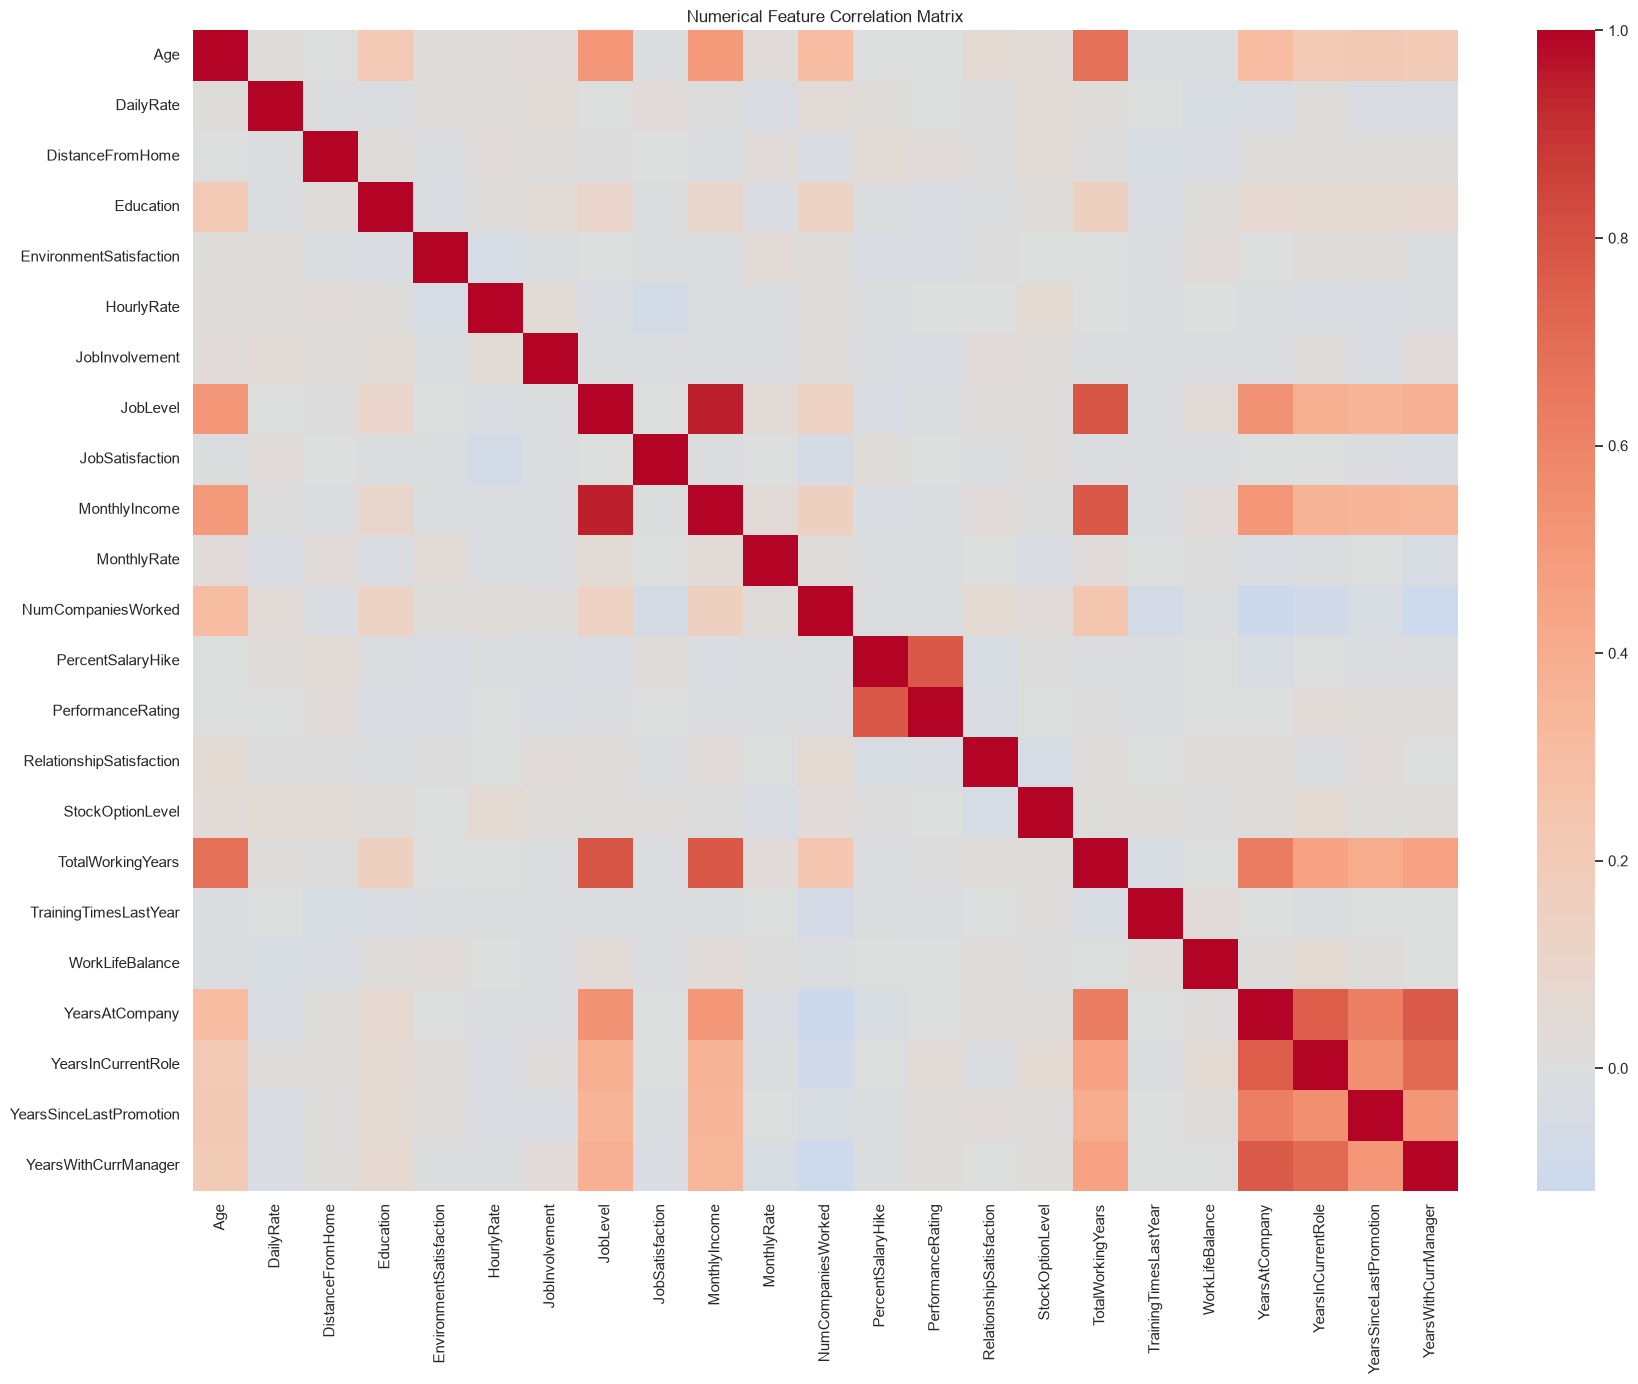

In [20]:
correlation_matrix = clean_df[
    numerical_features_eda
].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
)

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Selected Pairwise Relationships

A pair plot is restricted to a small set of important features to maintain readability and computational efficiency.

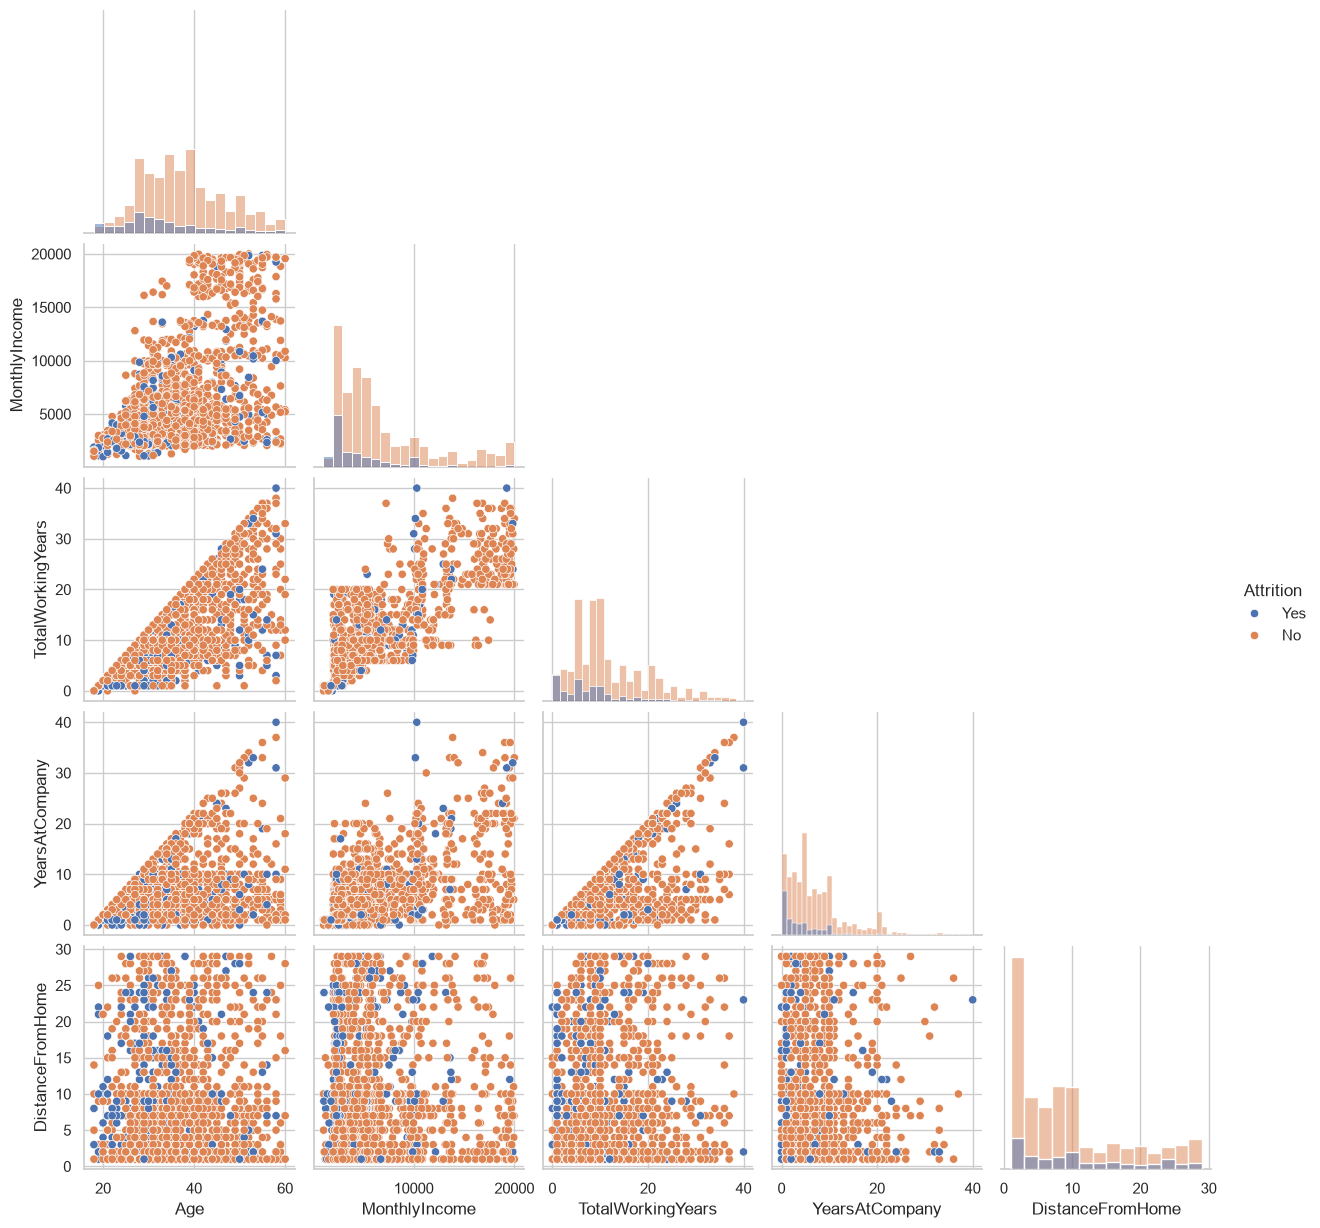

In [21]:
pairplot_features = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "DistanceFromHome",
    target_column,
]

sns.pairplot(
    clean_df[pairplot_features],
    hue=target_column,
    corner=True,
    diag_kind="hist",
)

plt.show()

## Phase 5: Data Preparation and Preprocessing Pipeline

The target is encoded as:

- `No = 0`
- `Yes = 1`

The preprocessing pipeline applies:

- Median imputation and standard scaling to numerical variables.
- Most-frequent imputation and one-hot encoding to categorical variables.

Random Forest does not require scaling, but the shared preprocessing pipeline makes model comparison consistent and supports models that depend on feature scale.

In [22]:
X = clean_df.drop(columns=[target_column]).copy()

y = (
    clean_df[target_column]
    .map({"No": 0, "Yes": 1})
    .astype(int)
)

numerical_features = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total raw features: {X.shape[1]}")

Numerical features: 23
Categorical features: 7
Total raw features: 30


## Phase 6: Stratified Train-Test Split

A stratified split preserves the attrition ratio in both training and test data. The test set remains isolated from model fitting and hyperparameter tuning.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "training_count": y_train.value_counts().sort_index(),
    "testing_count": y_test.value_counts().sort_index(),
    "training_percentage": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),
    "testing_percentage": (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),
})

split_summary.index = ["No Attrition", "Attrition"]

display(split_summary)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

,training_count,testing_count,training_percentage,testing_percentage
No Attrition,986,247,83.8435,84.0136
Attrition,190,47,16.1565,15.9864


Training shape: (1176, 30)
Testing shape: (294, 30)


## Phase 7: Baseline Random Forest

The baseline Random Forest uses balanced class weights to reduce bias toward the majority class.

The model is wrapped inside a complete preprocessing pipeline. This prevents leakage and ensures that the same transformations are applied during training and inference.

In [24]:
baseline_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

baseline_start_time = time.perf_counter()

baseline_rf_pipeline.fit(
    X_train,
    y_train,
)

baseline_training_time = (
    time.perf_counter() - baseline_start_time
)

baseline_predictions = baseline_rf_pipeline.predict(
    X_test
)

baseline_probabilities = (
    baseline_rf_pipeline.predict_proba(X_test)[:, 1]
)

baseline_metrics = {
    "accuracy": accuracy_score(
        y_test,
        baseline_predictions,
    ),
    "precision": precision_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        baseline_probabilities,
    ),
    "training_time_seconds": baseline_training_time,
}

display(
    pd.Series(
        baseline_metrics,
        name="Baseline Random Forest",
    ).to_frame()
)

,Baseline Random Forest
accuracy,0.8333
precision,0.4688
recall,0.3191
f1_score,0.3797
roc_auc,0.7796
training_time_seconds,0.7898


## Phase 8: Random Forest Hyperparameter Tuning

GridSearchCV tunes the parameters that control forest size, tree depth, node size, feature sampling, and class weighting.

The search is optimized using ROC-AUC because it evaluates probability ranking across thresholds and is appropriate for the imbalanced target.

In [25]:
tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 3],
    "model__max_features": ["sqrt"],
    "model__class_weight": ["balanced"],
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

tuning_start_time = time.perf_counter()

grid_search.fit(
    X_train,
    y_train,
)

tuning_time = (
    time.perf_counter() - tuning_start_time
)

best_rf_pipeline = grid_search.best_estimator_

print("Best Random Forest parameters:")
print(grid_search.best_params_)

print(
    f"Best cross-validation ROC-AUC: "
    f"{grid_search.best_score_:.4f}"
)

print(
    f"Total tuning time: "
    f"{tuning_time:.2f} seconds"
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Random Forest parameters:
{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
Best cross-validation ROC-AUC: 0.8085
Total tuning time: 102.11 seconds


### Cross-Validation Results

The ranked results compare training and validation ROC-AUC. A large gap between these values can indicate overfitting.

In [26]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)

cv_summary = cv_results[
    [
        "rank_test_score",
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "param_model__max_features",
        "param_model__class_weight",
    ]
].sort_values("rank_test_score")

display(cv_summary.head(15))

,rank_test_score,mean_train_score,std_train_score,mean_test_score,std_test_score,mean_fit_time,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__class_weight
3,1,1.0000,0.0000,0.8085,0.0287,5.9780,400,None,5,1,sqrt,balanced
1,2,1.0000,0.0000,0.8060,0.0308,7.2542,400,None,2,1,sqrt,balanced
2,3,1.0000,0.0000,0.8058,0.0313,3.9053,200,None,5,1,sqrt,balanced
5,4,0.9999,0.0002,0.8050,0.0297,6.2352,400,None,2,3,sqrt,balanced
7,4,0.9999,0.0002,0.8050,0.0297,6.5139,400,None,5,3,sqrt,balanced
0,6,1.0000,0.0000,0.8040,0.0347,3.0980,200,None,2,1,sqrt,balanced
4,7,0.9999,0.0001,0.8038,0.0275,3.5747,200,None,2,3,sqrt,balanced
6,7,0.9999,0.0001,0.8038,0.0275,4.0388,200,None,5,3,sqrt,balanced
15,9,0.9996,0.0002,0.8033,0.0294,7.3161,400,10,5,3,sqrt,balanced
13,9,0.9996,0.0002,0.8033,0.0294,6.6707,400,10,2,3,sqrt,balanced


## Phase 9: Tuned Random Forest Evaluation

The tuned Random Forest is evaluated using:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC-AUC.
- Confusion matrix.
- ROC curve.
- Precision-recall curve.

The positive class is employee attrition.

In [27]:
tuned_predictions = best_rf_pipeline.predict(X_test)

tuned_probabilities = (
    best_rf_pipeline.predict_proba(X_test)[:, 1]
)

tuned_metrics = {
    "accuracy": accuracy_score(
        y_test,
        tuned_predictions,
    ),
    "precision": precision_score(
        y_test,
        tuned_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        tuned_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        tuned_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        tuned_probabilities,
    ),
}

rf_before_after = pd.DataFrame({
    "Baseline Random Forest": pd.Series(
        baseline_metrics
    ),
    "Tuned Random Forest": pd.Series(
        tuned_metrics
    ),
})

display(rf_before_after)

print("Tuned Random Forest classification report:")

print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=[
            "No Attrition",
            "Attrition",
        ],
        digits=4,
    )
)

,Baseline Random Forest,Tuned Random Forest
accuracy,0.8333,0.8299
f1_score,0.3797,0.4048
precision,0.4688,0.4595
recall,0.3191,0.3617
roc_auc,0.7796,0.7862
training_time_seconds,0.7898,NaN


Tuned Random Forest classification report:
              precision    recall  f1-score   support

No Attrition     0.8833    0.9190    0.9008       247
   Attrition     0.4595    0.3617    0.4048        47

    accuracy                         0.8299       294
   macro avg     0.6714    0.6404    0.6528       294
weighted avg     0.8155    0.8299    0.8215       294



### Confusion Matrix

The confusion matrix highlights false negatives, which represent employees who left but were predicted to remain.

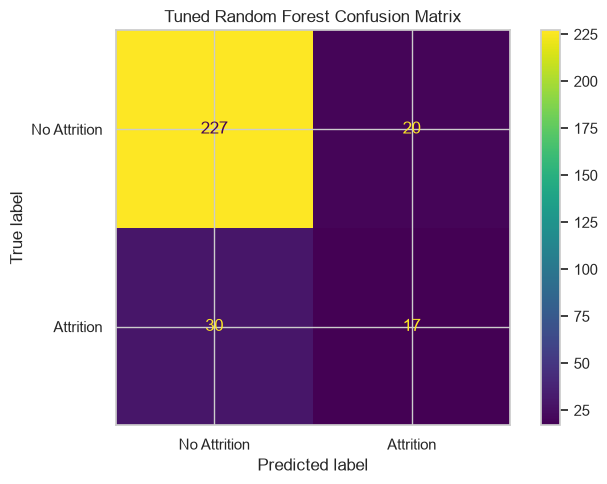

True negatives: 227
False positives: 20
False negatives: 30
True positives: 17


In [28]:
tuned_confusion_matrix = confusion_matrix(
    y_test,
    tuned_predictions,
)

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=[
        "No Attrition",
        "Attrition",
    ],
).plot(
    ax=ax,
    values_format="d",
)

ax.set_title("Tuned Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = tuned_confusion_matrix.ravel()

print(f"True negatives: {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives: {tp}")

### ROC Curve

The ROC curve summarizes ranking performance across classification thresholds.

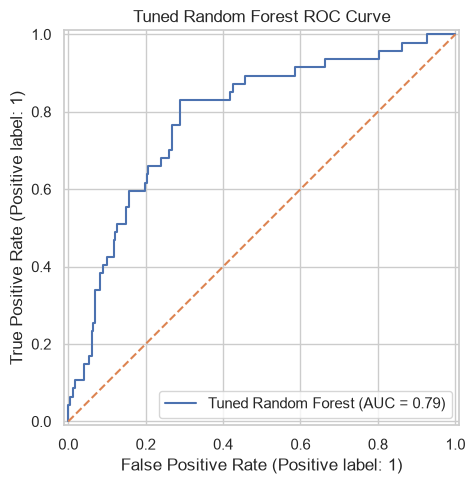

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    tuned_probabilities,
    name="Tuned Random Forest",
    ax=ax,
)

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Tuned Random Forest ROC Curve")

plt.tight_layout()
plt.show()

### Precision-Recall Curve

The precision-recall curve is especially informative when the positive class is relatively uncommon.

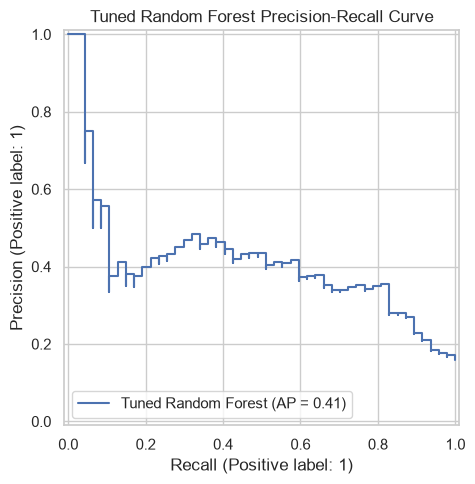

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    tuned_probabilities,
    name="Tuned Random Forest",
    ax=ax,
)

ax.set_title("Tuned Random Forest Precision-Recall Curve")

plt.tight_layout()
plt.show()

## Phase 10: Threshold Analysis

The default threshold of 0.50 may not produce the preferred balance between recall and precision.

Lower thresholds generally identify more employees at risk and increase recall, while also increasing false positives. The final threshold should reflect the cost of retention interventions and missed attrition cases.

In [31]:
threshold_results = []

for threshold in np.arange(0.15, 0.76, 0.05):
    threshold_predictions = (
        tuned_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(
            y_test,
            threshold_predictions,
        ),
        "precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0,
        ),
        "predicted_attrition_cases": int(
            threshold_predictions.sum()
        ),
    })

threshold_comparison = pd.DataFrame(
    threshold_results
)

display(threshold_comparison)

best_f1_threshold_row = (
    threshold_comparison
    .sort_values("f1_score", ascending=False)
    .iloc[0]
)

print("Threshold with the highest test F1-score:")
display(best_f1_threshold_row.to_frame("value"))

,threshold,accuracy,precision,recall,f1_score,predicted_attrition_cases
0,0.1500,0.3231,0.1833,0.9362,0.3066,240
1,0.2000,0.4898,0.2275,0.9149,0.3644,189
2,0.2500,0.6293,0.2786,0.8298,0.4171,140
3,0.3000,0.7245,0.3426,0.7872,0.4774,108
4,0.3500,0.7687,0.3636,0.5957,0.4516,77
5,0.4000,0.7993,0.4032,0.5319,0.4587,62
6,0.4500,0.8163,0.4314,0.4681,0.4490,51
7,0.5000,0.8299,0.4595,0.3617,0.4048,37
8,0.5500,0.8231,0.4000,0.2128,0.2778,25
9,0.6000,0.8299,0.4118,0.1489,0.2188,17


Threshold with the highest test F1-score:


,value
threshold,0.3000
accuracy,0.7245
precision,0.3426
recall,0.7872
f1_score,0.4774
predicted_attrition_cases,108.0000


## Phase 11: Random Forest Feature Importance

Feature importance measures the total reduction in impurity attributed to each transformed feature across the forest.

The values describe model usage and should not be interpreted as causal effects.

,feature,importance
0,MonthlyIncome,0.0771
1,Age,0.0623
2,TotalWorkingYears,0.0537
3,DailyRate,0.0522
4,YearsAtCompany,0.0500
5,OverTime_Yes,0.0495
6,HourlyRate,0.0445
7,MonthlyRate,0.0434
8,DistanceFromHome,0.0429
9,YearsWithCurrManager,0.0423


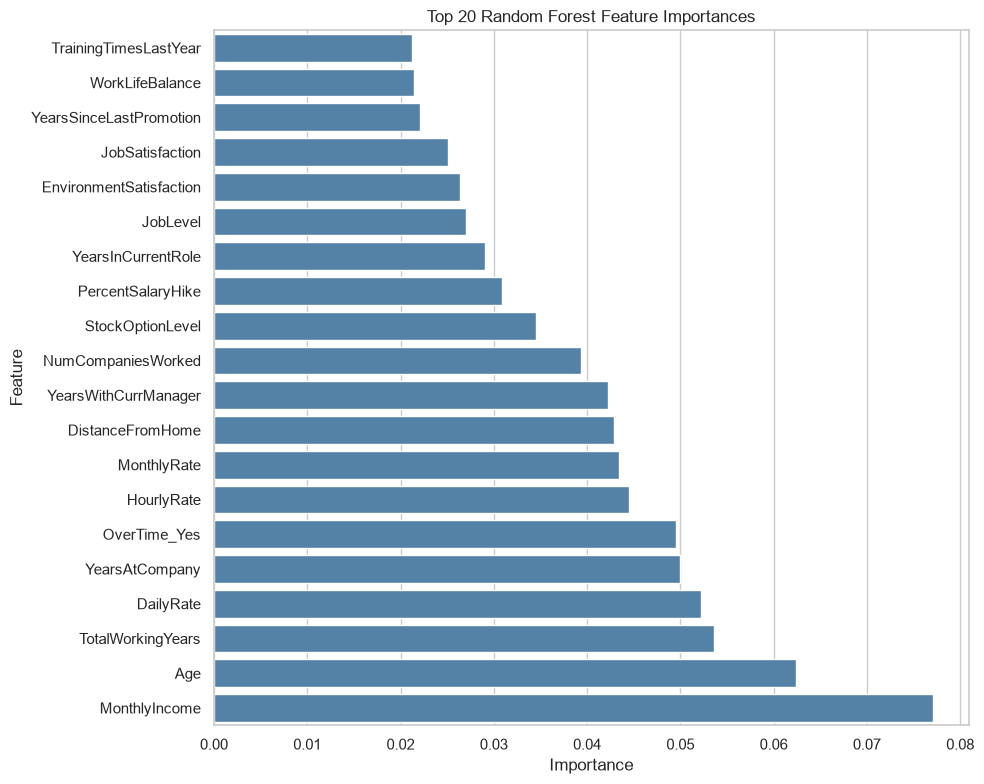

In [32]:
fitted_preprocessor = (
    best_rf_pipeline.named_steps["preprocessor"]
)

fitted_rf_model = (
    best_rf_pipeline.named_steps["model"]
)

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

feature_importance_df = (
    pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": (
            fitted_rf_model.feature_importances_
        ),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(25))

plot_importance = (
    feature_importance_df
    .head(20)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=plot_importance,
    x="importance",
    y="feature",
    color="steelblue",
)

plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Phase 12: Classification Model Comparison

The following models are compared using the same training and test split:

- Logistic Regression.
- Decision Tree.
- Baseline Random Forest.
- Tuned Random Forest.
- Extra Trees.
- Gradient Boosting.
- AdaBoost.
- K-Nearest Neighbors.
- Support Vector Machine.
- Gaussian Naive Bayes.
- XGBoost when installed.

Each model is evaluated using the same preprocessing pipeline.

In [33]:
comparison_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Baseline Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7,
    ),
    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Gaussian Naive Bayes": GaussianNB(),
}

if XGBOOST_AVAILABLE:
    comparison_models["XGBoost"] = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.90,
        colsample_bytree=0.90,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

comparison_results = []
trained_comparison_pipelines = {}

for model_name, model in comparison_models.items():
    comparison_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                model,
            ),
        ]
    )

    start_time = time.perf_counter()

    comparison_pipeline.fit(
        X_train,
        y_train,
    )

    training_time = (
        time.perf_counter() - start_time
    )

    predictions = comparison_pipeline.predict(
        X_test
    )

    probabilities = (
        comparison_pipeline.predict_proba(
            X_test
        )[:, 1]
    )

    comparison_results.append({
        "model": model_name,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities,
        ),
        "training_time_seconds": training_time,
    })

    trained_comparison_pipelines[
        model_name
    ] = comparison_pipeline

comparison_results.append({
    "model": "Tuned Random Forest",
    "accuracy": tuned_metrics["accuracy"],
    "precision": tuned_metrics["precision"],
    "recall": tuned_metrics["recall"],
    "f1_score": tuned_metrics["f1_score"],
    "roc_auc": tuned_metrics["roc_auc"],
    "training_time_seconds": tuning_time,
})

model_comparison_df = (
    pd.DataFrame(comparison_results)
    .sort_values(
        by=["roc_auc", "f1_score"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(model_comparison_df)

,model,accuracy,precision,recall,f1_score,roc_auc,training_time_seconds
0,Support Vector Machine,0.8163,0.4444,0.5957,0.5091,0.8054,0.5017
1,Logistic Regression,0.7551,0.3563,0.6596,0.4627,0.8035,0.1891
2,AdaBoost,0.8469,1.0000,0.0426,0.0816,0.7966,0.8615
3,Gradient Boosting,0.8503,0.5882,0.2128,0.3125,0.7944,0.6220
4,XGBoost,0.8639,0.7333,0.2340,0.3548,0.7942,0.3677
5,Extra Trees,0.8571,0.7273,0.1702,0.2759,0.7929,1.1266
6,Tuned Random Forest,0.8299,0.4595,0.3617,0.4048,0.7862,102.1083
7,Baseline Random Forest,0.8333,0.4688,0.3191,0.3797,0.7796,0.9219
8,Gaussian Naive Bayes,0.6156,0.2500,0.7021,0.3687,0.6956,0.0321
9,Decision Tree,0.7721,0.3571,0.5319,0.4274,0.6517,0.0426


### Model Comparison Visualizations

ROC-AUC shows threshold-independent ranking ability. F1-score shows the balance between precision and recall at the default classification threshold.

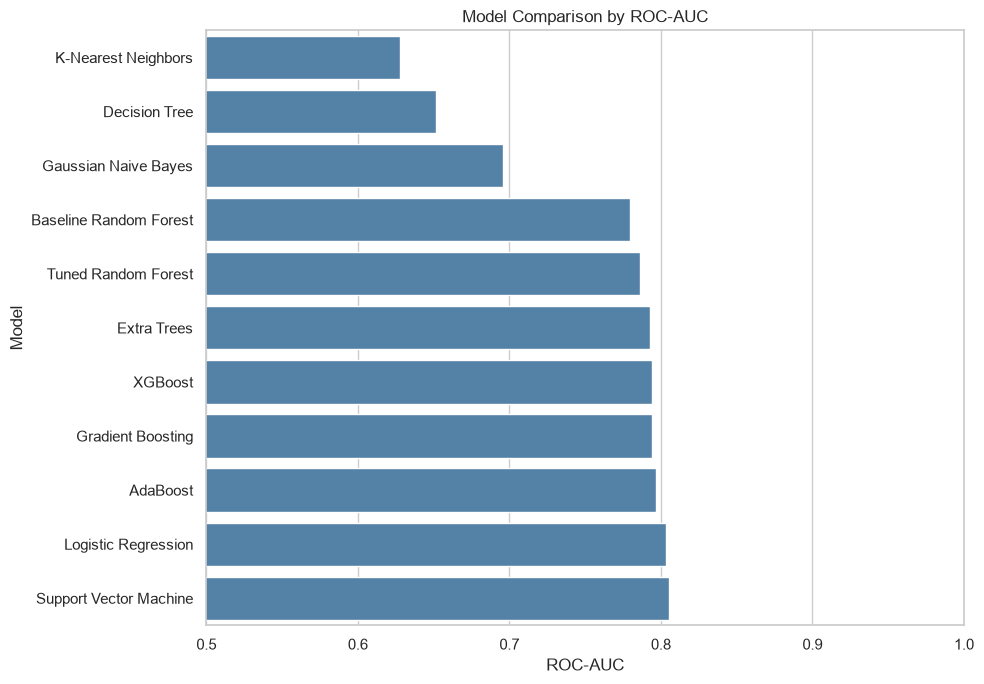

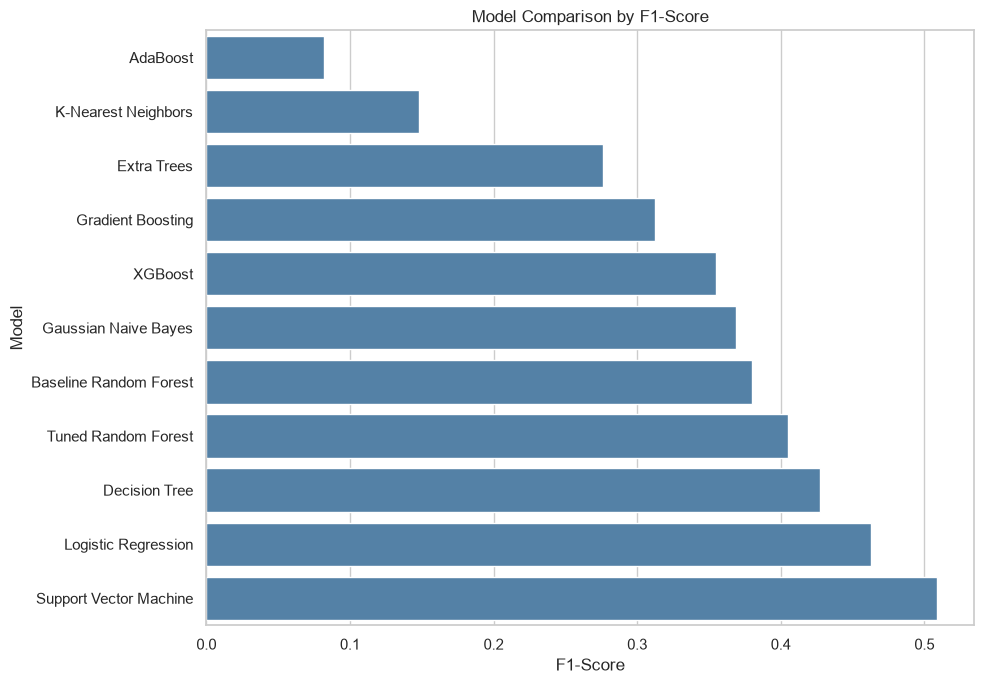

In [34]:
roc_plot_data = (
    model_comparison_df
    .sort_values("roc_auc", ascending=True)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=roc_plot_data,
    x="roc_auc",
    y="model",
    color="steelblue",
)

plt.title("Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.xlim(0.50, 1.00)
plt.tight_layout()
plt.show()

f1_plot_data = (
    model_comparison_df
    .sort_values("f1_score", ascending=True)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=f1_plot_data,
    x="f1_score",
    y="model",
    color="steelblue",
)

plt.title("Model Comparison by F1-Score")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### Final Model Selection

The highest ROC-AUC model is selected, with F1-score used as a secondary ranking criterion.

The selected model should still be reviewed from business, fairness, stability, and interpretability perspectives before deployment.

In [35]:
best_model_row = model_comparison_df.iloc[0]

display(
    best_model_row.to_frame("value")
)

if best_model_row["model"] == "Tuned Random Forest":
    final_pipeline = best_rf_pipeline
else:
    final_pipeline = (
        trained_comparison_pipelines[
            best_model_row["model"]
        ]
    )

print(
    f"Selected final model: "
    f"{best_model_row['model']}"
)

,value
model,Support Vector Machine
accuracy,0.8163
precision,0.4444
recall,0.5957
f1_score,0.5091
roc_auc,0.8054
training_time_seconds,0.5017


Selected final model: Support Vector Machine


## Phase 13: Final Reusable Random Forest Function

The function below provides a reusable interface for training and evaluating a Random Forest attrition model.

Editable parameters include:

- Test size.
- Number of trees.
- Maximum tree depth.
- Minimum samples required to split.
- Minimum samples required in a leaf.
- Number of sampled features.
- Class weighting.
- Split criterion.
- Bootstrap sampling.
- Classification threshold.

The function returns the fitted pipeline, predictions, probabilities, metrics, feature importance, confusion matrix, classification report, and train-test subsets.

In [36]:
def train_random_forest_hr_model(
    data,
    target_column="Attrition",
    drop_columns=(
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours",
    ),
    test_size=0.20,
    random_state=42,
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    criterion="gini",
    bootstrap=True,
    classification_threshold=0.50,
):
    working_data = data.copy()

    available_drop_columns = [
        column
        for column in drop_columns
        if column in working_data.columns
    ]

    working_data = working_data.drop(
        columns=available_drop_columns
    )

    if target_column not in working_data.columns:
        raise KeyError(
            f"Target column '{target_column}' "
            "was not found."
        )

    target_mapping = {
        "No": 0,
        "Yes": 1,
    }

    y_local = (
        working_data[target_column]
        .map(target_mapping)
    )

    if y_local.isna().any():
        unexpected_values = (
            working_data.loc[
                y_local.isna(),
                target_column,
            ]
            .unique()
            .tolist()
        )

        raise ValueError(
            "Unexpected target values were detected: "
            f"{unexpected_values}"
        )

    y_local = y_local.astype(int)

    X_local = working_data.drop(
        columns=[target_column]
    )

    numerical_local = (
        X_local
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical_local = (
        X_local
        .select_dtypes(exclude=np.number)
        .columns
        .tolist()
    )

    numerical_local_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_local_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),
            (
                "encoder",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )

    local_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numerical",
                numerical_local_pipeline,
                numerical_local,
            ),
            (
                "categorical",
                categorical_local_pipeline,
                categorical_local,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    (
        X_train_local,
        X_test_local,
        y_train_local,
        y_test_local,
    ) = train_test_split(
        X_local,
        y_local,
        test_size=test_size,
        random_state=random_state,
        stratify=y_local,
    )

    random_forest_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        criterion=criterion,
        bootstrap=bootstrap,
        random_state=random_state,
        n_jobs=-1,
    )

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                local_preprocessor,
            ),
            (
                "model",
                random_forest_model,
            ),
        ]
    )

    training_start_time = time.perf_counter()

    model_pipeline.fit(
        X_train_local,
        y_train_local,
    )

    training_time = (
        time.perf_counter()
        - training_start_time
    )

    probabilities = (
        model_pipeline.predict_proba(
            X_test_local
        )[:, 1]
    )

    predictions = (
        probabilities
        >= classification_threshold
    ).astype(int)

    metrics = {
        "accuracy": accuracy_score(
            y_test_local,
            predictions,
        ),
        "precision": precision_score(
            y_test_local,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test_local,
            predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test_local,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_test_local,
            probabilities,
        ),
        "training_time_seconds": training_time,
        "classification_threshold":
            classification_threshold,
    }

    fitted_local_preprocessor = (
        model_pipeline.named_steps[
            "preprocessor"
        ]
    )

    fitted_local_model = (
        model_pipeline.named_steps["model"]
    )

    transformed_names = (
        fitted_local_preprocessor
        .get_feature_names_out()
    )

    importance = (
        pd.DataFrame({
            "feature": transformed_names,
            "importance": (
                fitted_local_model
                .feature_importances_
            ),
        })
        .sort_values(
            "importance",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    confusion = confusion_matrix(
        y_test_local,
        predictions,
    )

    report = classification_report(
        y_test_local,
        predictions,
        target_names=[
            "No Attrition",
            "Attrition",
        ],
        output_dict=True,
        zero_division=0,
    )

    return {
        "pipeline": model_pipeline,
        "metrics": metrics,
        "feature_importance": importance,
        "predictions": predictions,
        "probabilities": probabilities,
        "confusion_matrix": confusion,
        "classification_report": report,
        "X_train": X_train_local,
        "X_test": X_test_local,
        "y_train": y_train_local,
        "y_test": y_test_local,
        "numerical_features": numerical_local,
        "categorical_features": categorical_local,
    }

### Example Custom Random Forest Experiment

Modify the function arguments to experiment with different Random Forest configurations without rewriting the full workflow.

In [37]:
custom_rf_experiment = train_random_forest_hr_model(
    data=df,
    n_estimators=600,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    criterion="gini",
    bootstrap=True,
    classification_threshold=0.35,
)

display(
    pd.Series(
        custom_rf_experiment["metrics"],
        name="Custom Random Forest Experiment",
    ).to_frame()
)

display(
    custom_rf_experiment[
        "feature_importance"
    ].head(20)
)

,Custom Random Forest Experiment
accuracy,0.7721
precision,0.3810
recall,0.6809
f1_score,0.4885
roc_auc,0.7777
training_time_seconds,3.4530
classification_threshold,0.3500


,feature,importance
0,MonthlyIncome,0.0767
1,Age,0.0634
2,TotalWorkingYears,0.0554
3,OverTime_Yes,0.0528
4,YearsAtCompany,0.0514
5,DailyRate,0.0505
6,DistanceFromHome,0.0446
7,YearsWithCurrManager,0.0429
8,HourlyRate,0.0416
9,MonthlyRate,0.0411


## Phase 14: Saving Processed Data, Reports, Figures, and Model Artifacts

The complete selected pipeline is serialized as a single production artifact. The notebook also exports:

- Cleaned dataset.
- Model comparison report.
- Feature importance report.
- Evaluation metrics.
- Model metadata.
- Confusion matrix figure.
- ROC curve figure.
- Precision-recall curve figure.

In [38]:
if Path.cwd().name == "notebooks":
    project_root = Path("..")
else:
    project_root = Path(".")

model_directory = project_root / "models"
report_directory = project_root / "reports"
figure_directory = report_directory / "figures"
processed_directory = project_root / "data" / "processed"

for directory in [
    model_directory,
    report_directory,
    figure_directory,
    processed_directory,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

pipeline_path = (
    model_directory
    / "hr_attrition_classification_pipeline.joblib"
)

metadata_path = (
    model_directory
    / "hr_attrition_model_metadata.joblib"
)

processed_data_path = (
    processed_directory
    / "hr_attrition_cleaned.csv"
)

comparison_path = (
    report_directory
    / "model_comparison.csv"
)

feature_importance_path = (
    report_directory
    / "feature_importance.csv"
)

evaluation_metrics_path = (
    report_directory
    / "evaluation_metrics.csv"
)

clean_df.to_csv(
    processed_data_path,
    index=False,
)

model_comparison_df.to_csv(
    comparison_path,
    index=False,
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False,
)

pd.DataFrame(
    [tuned_metrics]
).to_csv(
    evaluation_metrics_path,
    index=False,
)

model_metadata = {
    "target_column": target_column,
    "target_mapping": {
        "No": 0,
        "Yes": 1,
    },
    "selected_model": best_model_row["model"],
    "input_features": X.columns.tolist(),
    "dropped_columns": columns_to_drop,
    "best_random_forest_parameters":
        grid_search.best_params_,
    "model_comparison":
        model_comparison_df.to_dict("records"),
}

joblib.dump(
    final_pipeline,
    pipeline_path,
)

joblib.dump(
    model_metadata,
    metadata_path,
)

print(
    f"Pipeline saved to: "
    f"{pipeline_path.resolve()}"
)

print(
    f"Metadata saved to: "
    f"{metadata_path.resolve()}"
)

print(
    f"Processed data saved to: "
    f"{processed_data_path.resolve()}"
)

print(
    f"Reports saved to: "
    f"{report_directory.resolve()}"
)

Pipeline saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\04_RandomForest_HRAttrition\models\hr_attrition_classification_pipeline.joblib
Metadata saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\04_RandomForest_HRAttrition\models\hr_attrition_model_metadata.joblib
Processed data saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\04_RandomForest_HRAttrition\data\processed\hr_attrition_cleaned.csv
Reports saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\04_RandomForest_HRAttrition\reports


### Saving Evaluation Figures

The core evaluation figures are recreated and saved with publication-ready resolution.

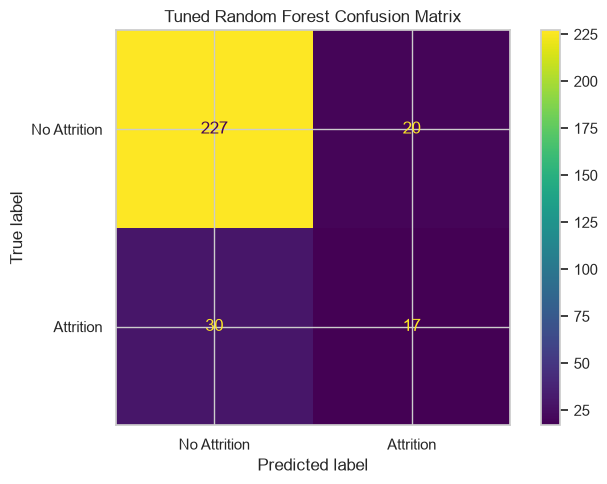

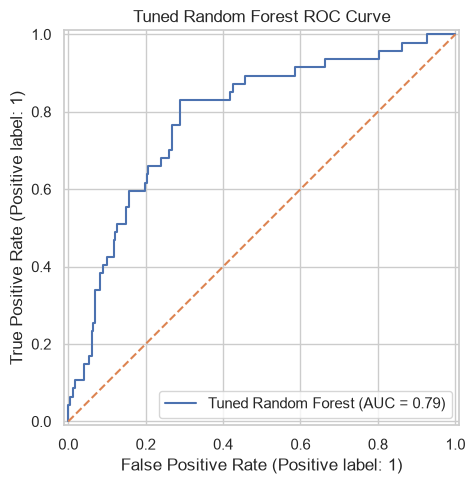

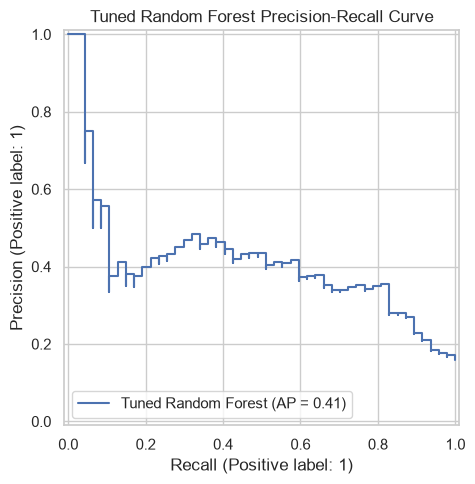

Figures saved to: C:\Users\soham\Desktop\ahmed\NTI-ML\04_RandomForest_HRAttrition\reports\figures


In [39]:
confusion_figure_path = (
    figure_directory
    / "random_forest_confusion_matrix.png"
)

roc_figure_path = (
    figure_directory
    / "random_forest_roc_curve.png"
)

precision_recall_figure_path = (
    figure_directory
    / "random_forest_precision_recall_curve.png"
)

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=[
        "No Attrition",
        "Attrition",
    ],
).plot(
    ax=ax,
    values_format="d",
)

ax.set_title(
    "Tuned Random Forest Confusion Matrix"
)

plt.tight_layout()
plt.savefig(
    confusion_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    tuned_probabilities,
    name="Tuned Random Forest",
    ax=ax,
)

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Tuned Random Forest ROC Curve")

plt.tight_layout()
plt.savefig(
    roc_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    tuned_probabilities,
    name="Tuned Random Forest",
    ax=ax,
)

ax.set_title(
    "Tuned Random Forest Precision-Recall Curve"
)

plt.tight_layout()
plt.savefig(
    precision_recall_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    f"Figures saved to: "
    f"{figure_directory.resolve()}"
)

## Phase 15: Artifact Validation

The serialized pipeline is reloaded and tested on the original test set. This verifies that preprocessing and model inference remain valid after serialization.

In [40]:
reloaded_pipeline = joblib.load(
    pipeline_path
)

reloaded_metadata = joblib.load(
    metadata_path
)

reloaded_predictions = (
    reloaded_pipeline.predict(X_test)
)

original_predictions = (
    final_pipeline.predict(X_test)
)

if not np.array_equal(
    reloaded_predictions,
    original_predictions,
):
    raise ValueError(
        "Reloaded predictions do not match "
        "the original pipeline predictions."
    )

print("Artifact validation completed successfully.")

print(
    f"Validated model: "
    f"{reloaded_metadata['selected_model']}"
)

Artifact validation completed successfully.
Validated model: Support Vector Machine


## Final Conclusions

This project developed an end-to-end employee attrition classification system centered on Random Forest.

The completed workflow includes:

- Extensive data-quality assessment.
- More than twenty exploratory visualizations.
- Leakage-safe preprocessing.
- Baseline and tuned Random Forest models.
- Threshold analysis.
- Feature importance.
- Comparison with multiple classification algorithms.
- A reusable Random Forest training function.
- Saved model, metadata, reports, processed data, and figures.

Before production deployment, the organization should assess:

- Model fairness across employee groups.
- Probability calibration.
- Data drift.
- Changes in HR policy.
- The ethical use of employee data.
- Human review requirements.
- The business cost of false positives and false negatives.